In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from statsmodels.tsa.seasonal import seasonal_decompose

import torch
import numpy as np
import random
import os

# Set seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

# CUDA deterministic settings
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

In [3]:
import numpy as np
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import transforms

from ilipy import Session
from ilipy.database import DistanceCorrelation
from ilipy import  Session

from rnd.utils.modeling import get_model
from rnd.utils.transform import resize_to_224
from rnd.utils.data_utils import (
    set_ili_run,
    extract_arm_angles,
    create_arm_array,
)

In [4]:
run_number = 6
root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)
_, _, inspection_id, env, _, start_dist, end_dist = set_ili_run(run_number)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PySettings.cpp(46): ilipy: Build 0.17.2.10867 5d2ea142f2 release-ili-0.17 'Tue Jul 22 21:50:18 2025'
PySettings.cpp(47): Paths modulePath: /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy, userHomePath: /home/zmirikha, identityPath: /home/zmirikha/.aws/ilipy
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/defaults.json
Settings.cpp(246): Settings: loading settings from /home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/Data/Environments/research.json
PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DatabaseWebSocket.cpp(168): WebSoc

In [6]:
class PreprocessingModel(nn.Module):
    def __init__(self, model, transform):
        super().__init__()
        self.model = model
        self.transform = transform

    def forward(self, input_np_image):
        # Apply transform to NumPy image (expects single image, not batch)
        x = self.transform(input_np_image)
        x = x.unsqueeze(0)  # Add batch dimension
        return self.model(x)

In [7]:
def load_model(model_name, dense_units, dropout, model_path):
    """
    Load a PyTorch model with weights and return it along with the transform.

    Returns:
        model (torch.nn.Module): The loaded model ready for inference.
        transform (callable): The image preprocessing pipeline.
        weights: The weight metadata used for normalization.
    """
    model, weights = get_model(model_name, dense_units, dropout)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model, weights

    # transform = transforms.Compose([
    #     transforms.Lambda(resize_to_224),
    #     transforms.ToTensor(),
    #     transforms.Lambda(lambda x: x.expand(3, -1, -1)),
    #     transforms.Normalize(mean=weights.transforms().mean, std=weights.transforms().std),
    # ])

    # wrapped_model = PreprocessingModel(model, transform)
    #return wrapped_model

In [8]:
model, weights = load_model("resnet", 128, 0.5, "models/dent_models/resnet_final_40.pth")

In [9]:
transform = transforms.Compose(
    [
        transforms.Lambda(resize_to_224), # should output (C, H, W)
        transforms.Lambda(lambda x: torch.from_numpy(x).float()),
        transforms.Normalize(
            mean=weights.transforms().mean, std=weights.transforms().std
        ),
    ]
)

In [10]:
def gen_image(img_start, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=22,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.show()
    return img

In [11]:
patch_length = 0.3
stride = 0.25
ranges = [(start, start + patch_length) for start in np.arange(start_dist, end_dist - patch_length + stride, stride)]

In [12]:
len(ranges)

4584

In [ ]:
# img_std_dir = os.path.join(root_dir, "img_std")
# img_patch_dir = os.path.join(root_dir, "img_patch")
# os.makedirs(img_std_dir, exist_ok=True)
# os.makedirs(img_patch_dir, exist_ok=True)
# for i, (img_start, img_end) in enumerate(ranges):
#         if i % 200 == 0:
#             print(f"Processing image {i}/{len(ranges)}")
#         vd = (img_start + img_end) / 2 #147828.385 -0.15#
#         img_std = gen_image(vd, show_im=False, normalize="std")
#         img_patch = gen_image(vd, show_im=False, normalize="patch")
#         np.save(os.path.join(img_std_dir, f"img_std_{vd*1000:.0f}.npy"), img_std)
#         np.save(os.path.join(img_patch_dir, f"img_patch_{vd*1000:.0f}.npy"), img_patch)

In [17]:
img_std_dir = os.path.join(root_dir, "img_std")
img_patch_dir = os.path.join(root_dir, "img_patch")
batch_size = 64
preds = []
probs = []
preds_list = {}

with torch.no_grad():
    model.eval()
    model.to(device)
    for batch_start in range(0, len(ranges), batch_size):
        print(f"Processing batch {batch_start // batch_size + 1}")
        batch_ranges = ranges[batch_start:batch_start + batch_size]
        imgs = []
        for img_start, img_end in batch_ranges:
            vd = (img_start + img_end) / 2
            img_std = np.load(os.path.join(img_std_dir, f"img_std_{vd*1000:.0f}.npy"))[:20, :]
            img_patch = np.load(os.path.join(img_patch_dir, f"img_patch_{vd*1000:.0f}.npy"))[:20, :]
            img_patch = np.nan_to_num(img_patch, nan=0.0, posinf=0.0, neginf=0.0)
            img_patch_trend = seasonal_decompose(img_patch.T, model='additive', period=30, extrapolate_trend=2).trend.T
            img = np.stack((img_patch, img_patch_trend, img_std), axis=0)  # shape: (3, H, W)
            img = transform(img)
            imgs.append(img)
        imgs = torch.stack(imgs, dim=0).to(device)  # shape: (batch_size, 3, H, W)
        raw_outputs = model(imgs)
        preds.extend(raw_outputs.argmax(dim=1).cpu().numpy())
        probs.extend(raw_outputs.sigmoid().max(dim=1).values.cpu().numpy())
        for br, raw_output in zip(batch_ranges, raw_outputs.sigmoid().cpu().numpy()):
            if raw_output.argmax() == 0:
                continue
            else:
                view_dist = (br[0] + br[1]) / 2
                preds_list[view_dist] = list((raw_output > 0.9).nonzero()[0])

Processing batch 1
Processing batch 2
Processing batch 3
Processing batch 4
Processing batch 5
Processing batch 6
Processing batch 7
Processing batch 8
Processing batch 9
Processing batch 10
Processing batch 11
Processing batch 12
Processing batch 13
Processing batch 14
Processing batch 15
Processing batch 16
Processing batch 17
Processing batch 18
Processing batch 19
Processing batch 20
Processing batch 21
Processing batch 22
Processing batch 23
Processing batch 24
Processing batch 25
Processing batch 26
Processing batch 27
Processing batch 28
Processing batch 29
Processing batch 30
Processing batch 31
Processing batch 32
Processing batch 33
Processing batch 34
Processing batch 35
Processing batch 36
Processing batch 37
Processing batch 38
Processing batch 39
Processing batch 40
Processing batch 41
Processing batch 42
Processing batch 43
Processing batch 44
Processing batch 45
Processing batch 46
Processing batch 47
Processing batch 48
Processing batch 49
Processing batch 50
Processin

In [18]:
#preds = [pred.cpu() for pred in preds]
np.save(os.path.join(root_dir, "preds4.npy"), np.array(preds))
np.save(os.path.join(root_dir, "probs4.npy"), np.array(probs))


In [ ]:
len(preds), len(probs)

In [ ]:
# preds = np.load(os.path.join(root_dir, "preds4.npy"))
# probs = np.load(os.path.join(root_dir, "probs4.npy"))

In [ ]:
len(preds), len(probs), len (ranges)

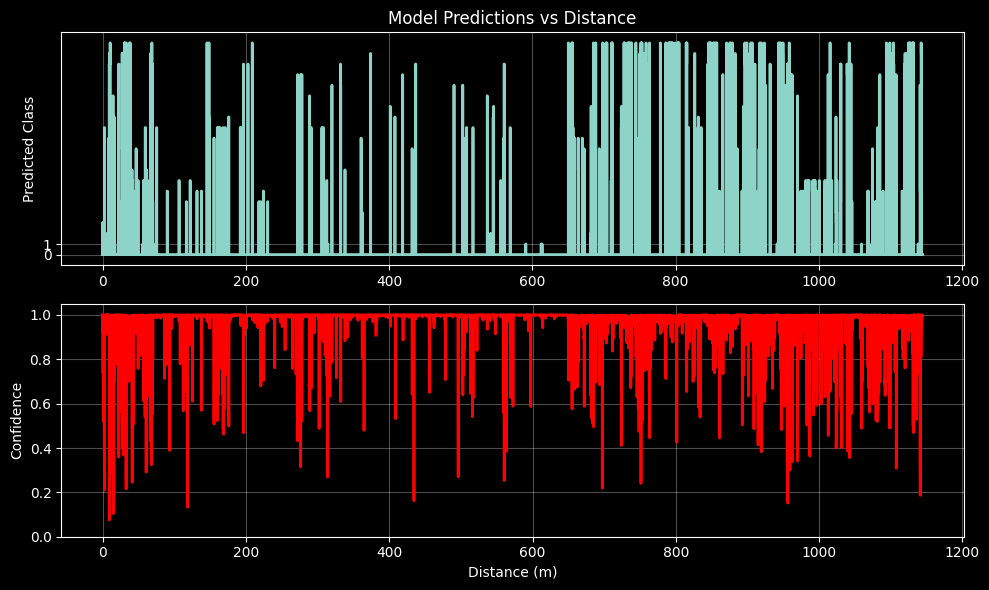

In [19]:
# Plot predictions
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Create x-axis points
patch_length = 0.3
x_points = [(img_start + img_end) / 2 for (img_start, img_end) in ranges]

# Plot class predictions (0 or 1)
plt.subplot(2, 1, 1)
plt.step(x_points, preds, where='mid', linewidth=2)
plt.ylabel('Predicted Class')
plt.title('Model Predictions vs Distance')
plt.grid(True, alpha=0.3)
plt.yticks([0, 1])

# Plot confidence probabilities
plt.subplot(2, 1, 2)
plt.plot(x_points, probs, 'r-', linewidth=2)
plt.xlabel('Distance (m)')
plt.ylabel('Confidence')
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

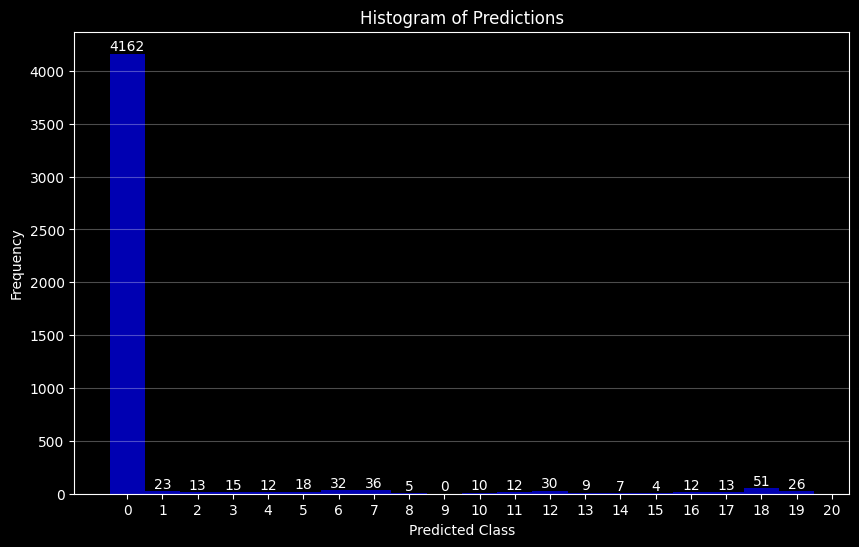

In [20]:
#histogram of preds
plt.figure(figsize=(10, 6))
plt.hist(preds, bins=np.arange(-0.5, 20, 1), alpha=0.7, color='blue')
plt.xticks(range(21))
plt.xlabel('Predicted Class')
plt.ylabel('Frequency')
plt.title('Histogram of Predictions')
#print fresquency on top of bars
for i in range(len(np.unique(preds))):
    plt.text(i, np.bincount(preds)[i], str(np.bincount(preds)[i]), ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)
plt.show()



In [21]:
def filter_consecutive(indices):
    if not indices:
        return []
    filtered = []
    group = [indices[0]]
    for i in range(1, len(indices)):
        if indices[i] == indices[i-1] + 1:
            group.append(indices[i])
        else:
            # End of a consecutive group
            filtered.append(group[len(group)//2])
            group = [indices[i]]
    # Add the last group
    filtered.append(group[len(group)//2])
    return filtered



195 positive indices found


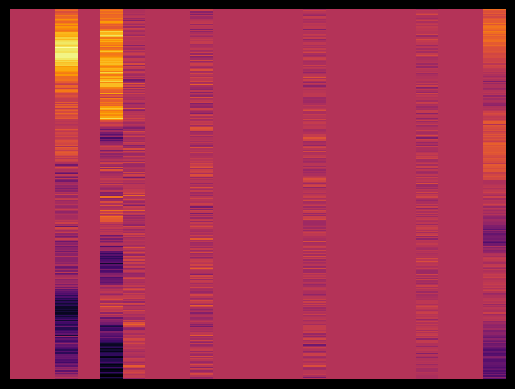

VD: -0.6 Prediction: 3 Probability: tensor(0.9244)
Predicted indices: [3]


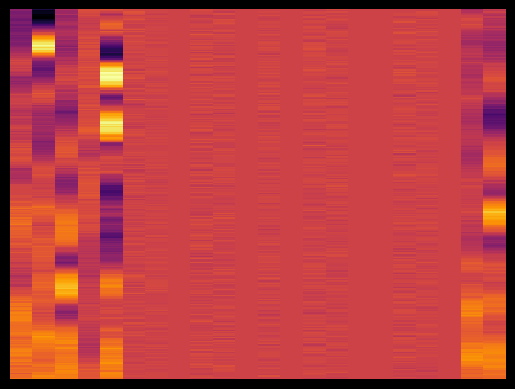

VD: 0.4 Prediction: 1 Probability: tensor(0.9567)
Predicted indices: [1]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


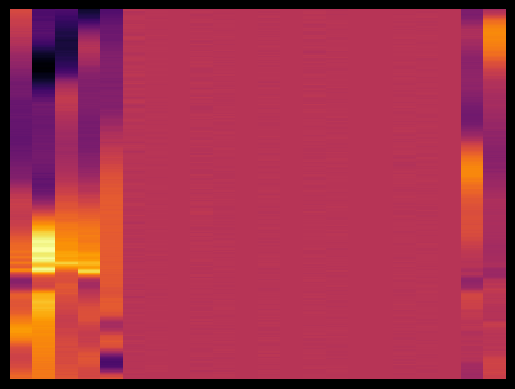

VD: 1.4 Prediction: 2 Probability: tensor(0.9941)
Predicted indices: [2, 3]


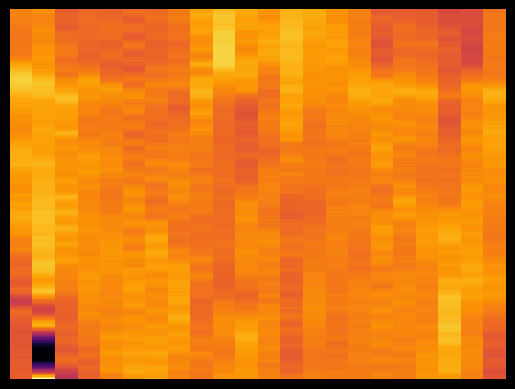

VD: 2.9 Prediction: 1 Probability: tensor(0.9989)
Predicted indices: [0, 1]


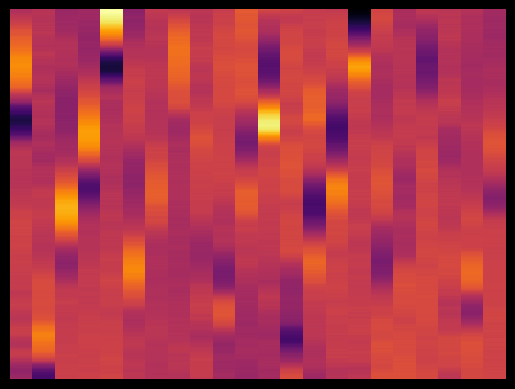

VD: 4.65 Prediction: 2 Probability: tensor(0.9125)
Predicted indices: [2]


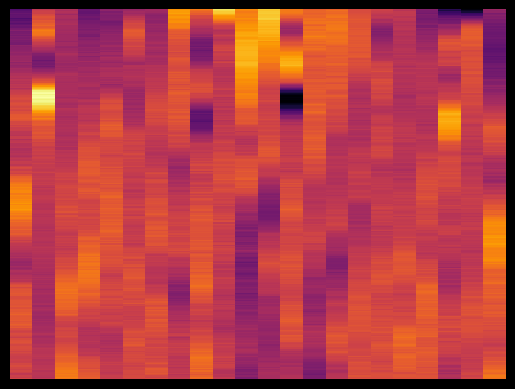

VD: 8.15 Prediction: 11 Probability: tensor(0.9728)
Predicted indices: [11, 12]


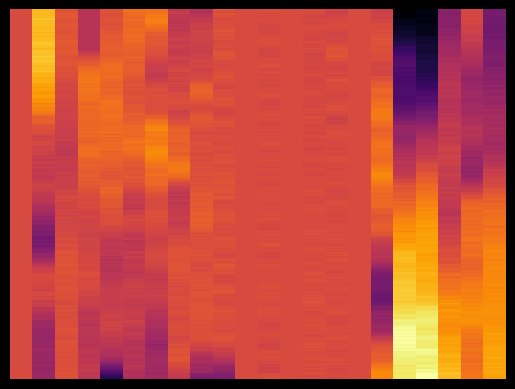

VD: 9.15 Prediction: 19 Probability: tensor(0.9963)
Predicted indices: [18, 19, 20]


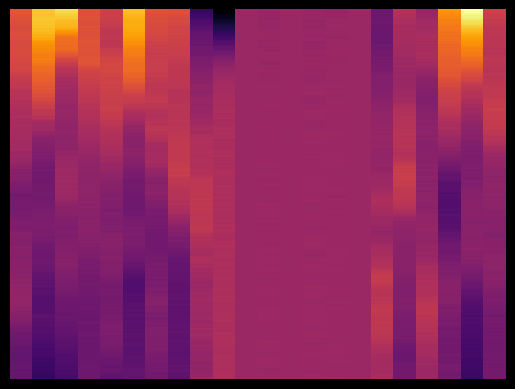

VD: 10.15 Prediction: 20 Probability: tensor(0.9973)
Predicted indices: [19, 20]


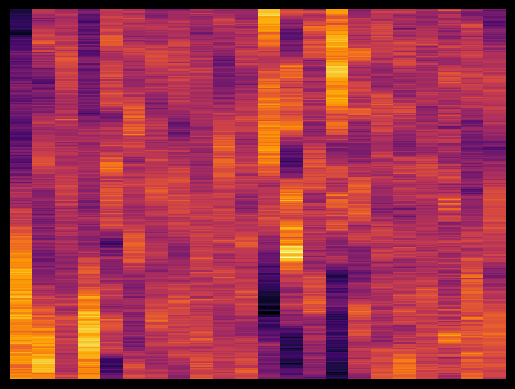

VD: 11.4 Prediction: 13 Probability: tensor(0.9985)
Predicted indices: [12, 13, 14]


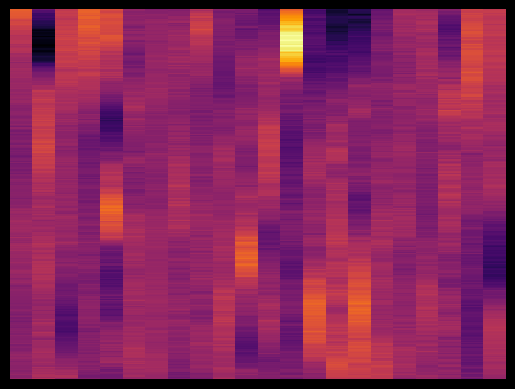

VD: 13.15 Prediction: 3 Probability: tensor(0.9686)
Predicted indices: [3, 4]


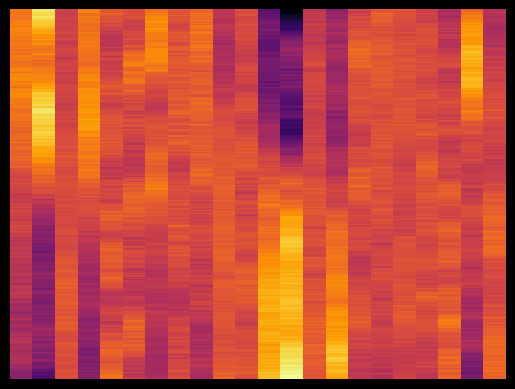

VD: 16.15 Prediction: 12 Probability: tensor(0.9958)
Predicted indices: [12, 13]


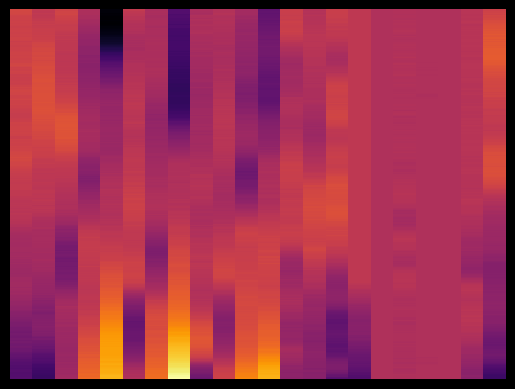

VD: 22.9 Prediction: 5 Probability: tensor(0.9169)
Predicted indices: [5]


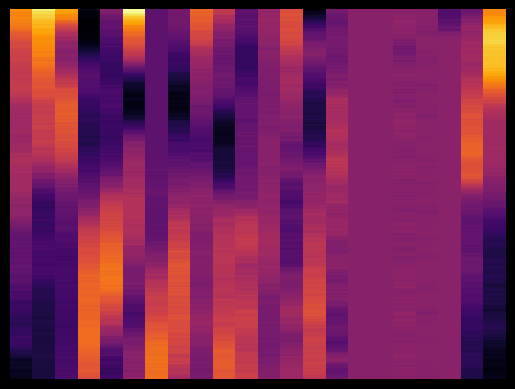

VD: 24.15 Prediction: 4 Probability: tensor(0.9993)
Predicted indices: [3, 4]


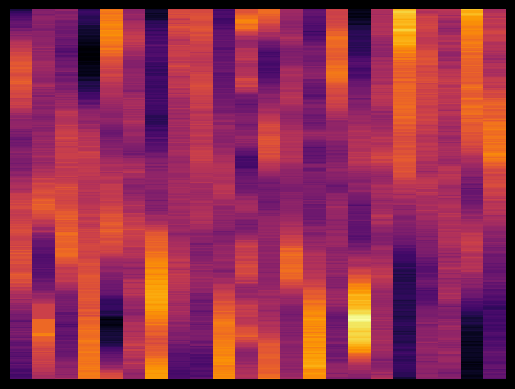

VD: 25.15 Prediction: 4 Probability: tensor(0.9719)
Predicted indices: [4]


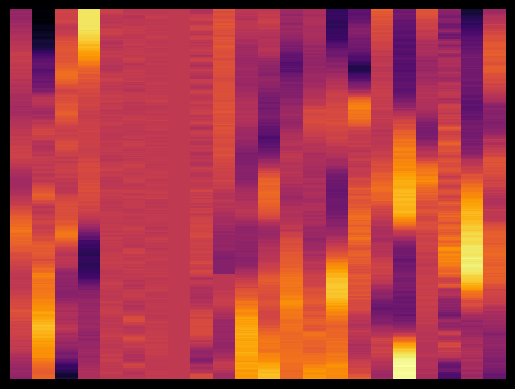

VD: 29.15 Prediction: 3 Probability: tensor(0.9598)
Predicted indices: [2, 3]


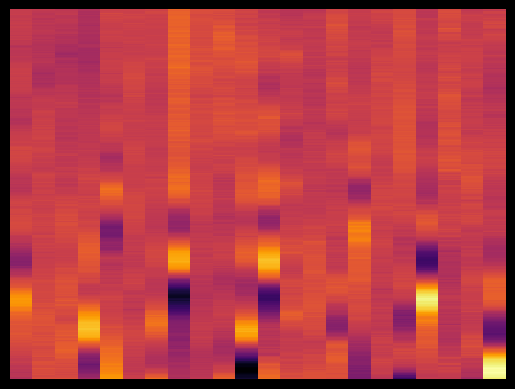

VD: 30.15 Prediction: 20 Probability: tensor(0.9942)
Predicted indices: [0, 20]


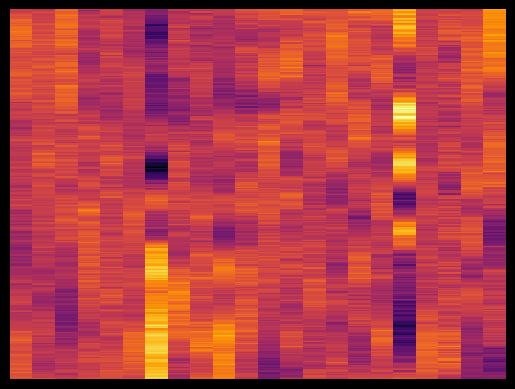

VD: 30.9 Prediction: 7 Probability: tensor(0.9978)
Predicted indices: [6, 7, 8]


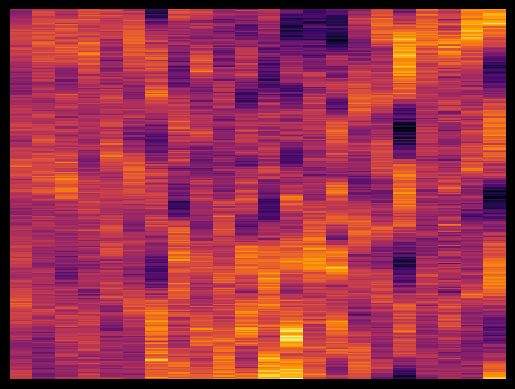

VD: 32.9 Prediction: 18 Probability: tensor(0.9249)
Predicted indices: [18]


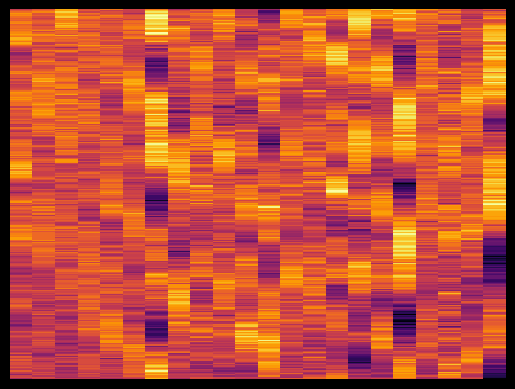

VD: 34.65 Prediction: 7 Probability: tensor(0.9962)
Predicted indices: [6, 7]


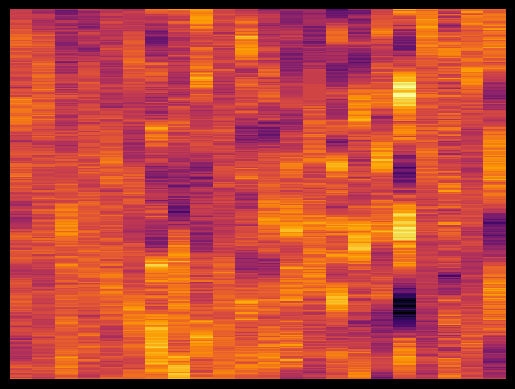

VD: 38.15 Prediction: 18 Probability: tensor(0.9895)
Predicted indices: [18, 19]


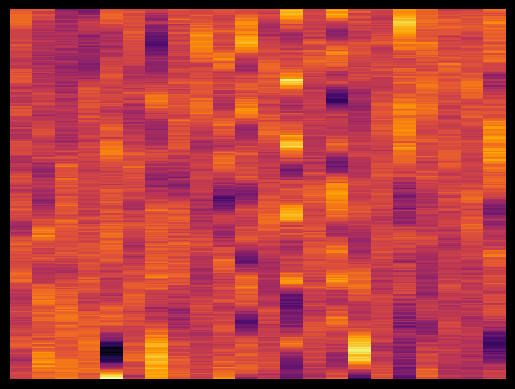

VD: 43.15 Prediction: 6 Probability: tensor(0.9702)
Predicted indices: [5, 6]


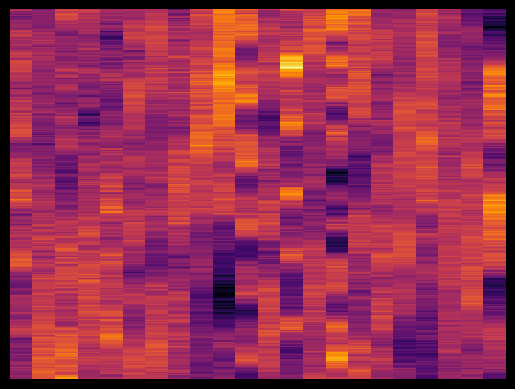

VD: 46.4 Prediction: 10 Probability: tensor(0.9286)
Predicted indices: [10]


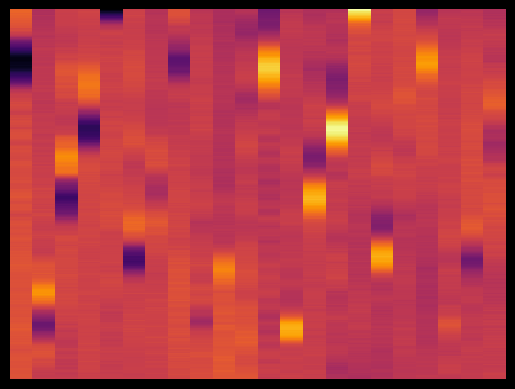

VD: 55.65 Prediction: 1 Probability: tensor(0.9652)
Predicted indices: [1, 2]


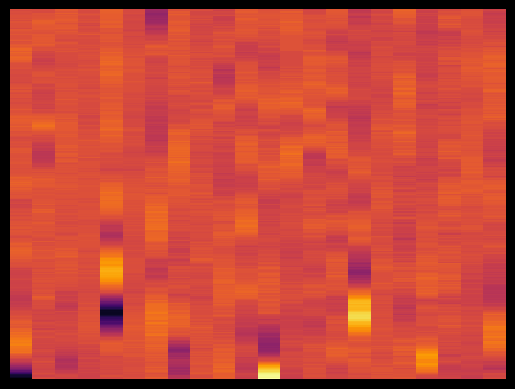

VD: 56.4 Prediction: 1 Probability: tensor(0.9858)
Predicted indices: [0, 1]


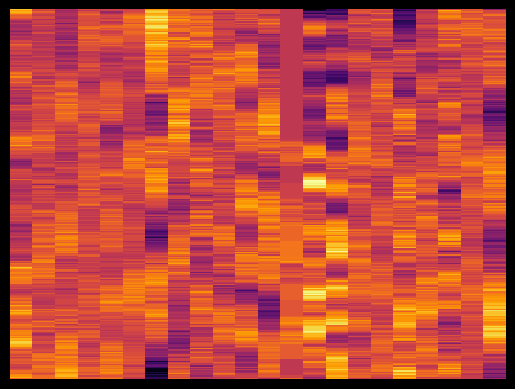

VD: 57.65 Prediction: 7 Probability: tensor(0.9986)
Predicted indices: [6, 7, 8]


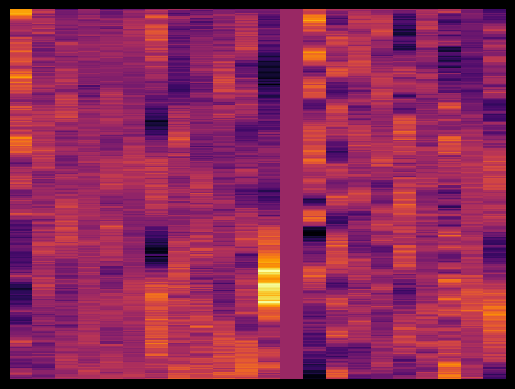

VD: 59.15 Prediction: 12 Probability: tensor(0.9861)
Predicted indices: [12, 13]


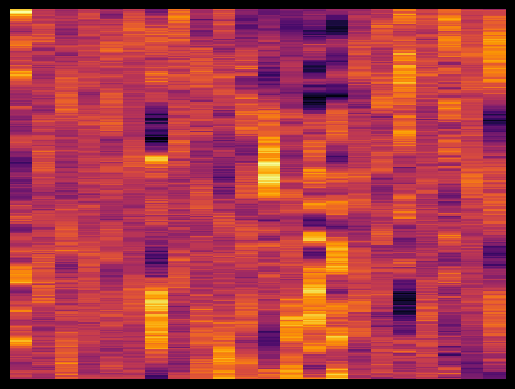

VD: 59.9 Prediction: 7 Probability: tensor(0.9638)
Predicted indices: [6, 7]


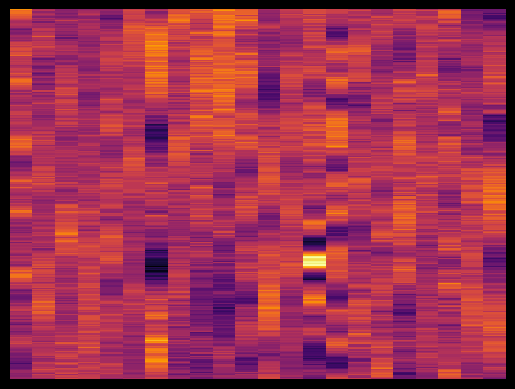

VD: 60.65 Prediction: 7 Probability: tensor(0.9979)
Predicted indices: [6, 7, 8]


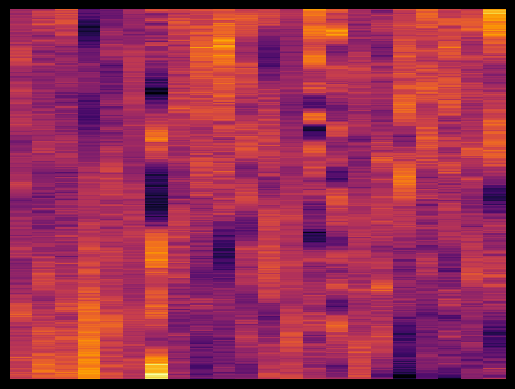

VD: 65.15 Prediction: 7 Probability: tensor(0.9920)
Predicted indices: [6, 7]


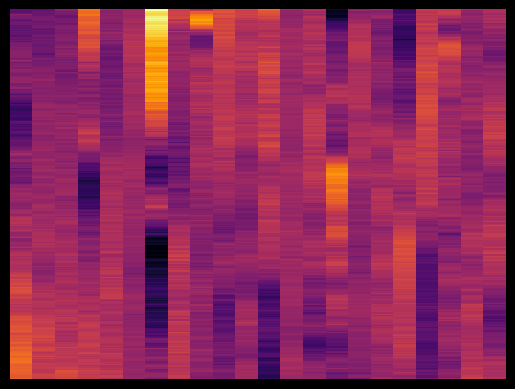

VD: 65.65 Prediction: 6 Probability: tensor(0.9970)
Predicted indices: [6, 7]


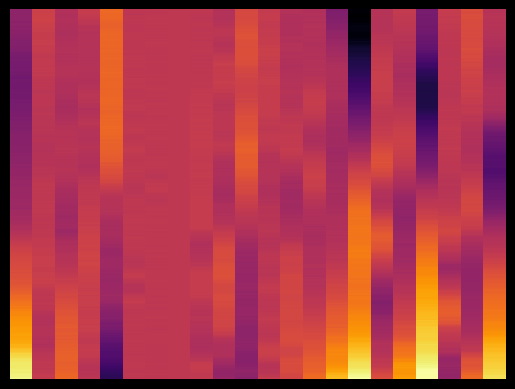

VD: 66.4 Prediction: 19 Probability: tensor(0.9981)
Predicted indices: [18, 19, 20]


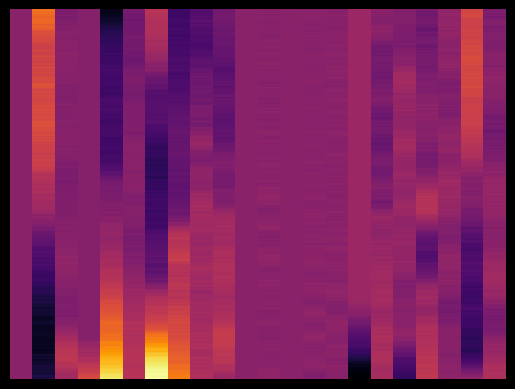

VD: 68.4 Prediction: 20 Probability: tensor(0.9159)
Predicted indices: [20]


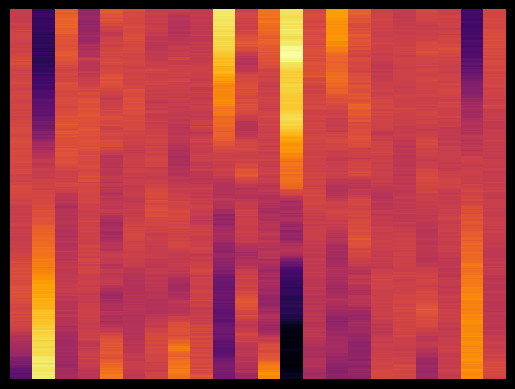

VD: 70.4 Prediction: 1 Probability: tensor(0.9969)
Predicted indices: [0, 1]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


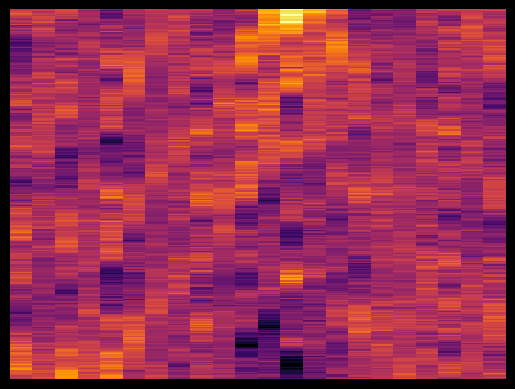

VD: 75.15 Prediction: 12 Probability: tensor(0.9862)
Predicted indices: [12, 13]


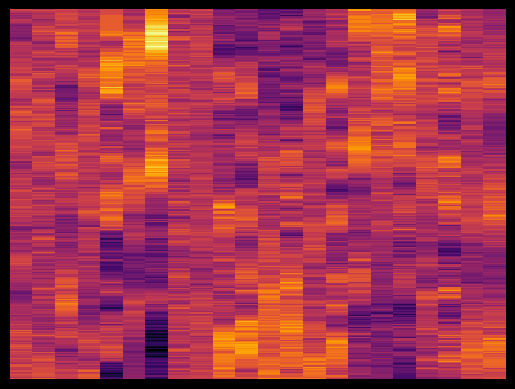

VD: 106.4 Prediction: 7 Probability: tensor(0.9716)
Predicted indices: [6, 7]


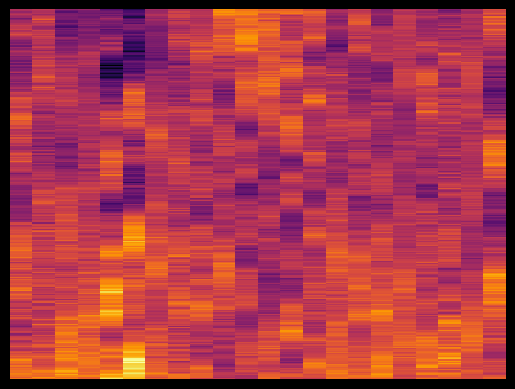

VD: 116.65 Prediction: 5 Probability: tensor(0.9811)
Predicted indices: [5, 6]


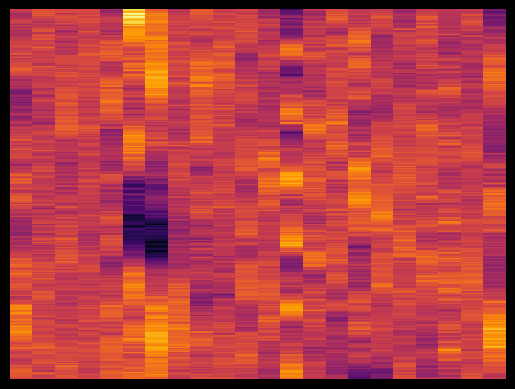

VD: 121.9 Prediction: 7 Probability: tensor(0.9996)
Predicted indices: [6, 7]


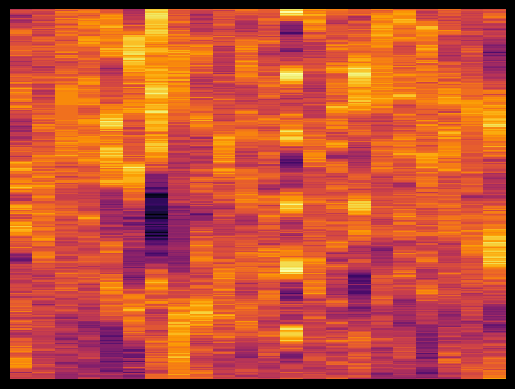

VD: 131.4 Prediction: 6 Probability: tensor(0.9821)
Predicted indices: [6, 7]


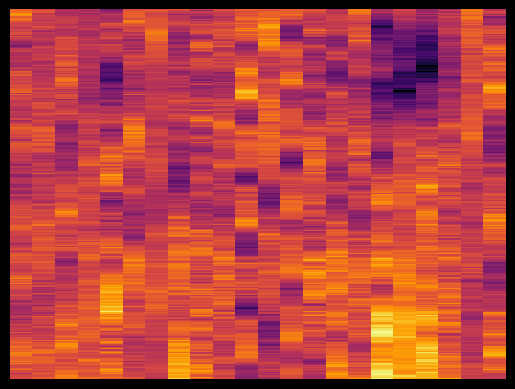

VD: 145.4 Prediction: 20 Probability: tensor(0.9728)
Predicted indices: [19, 20]


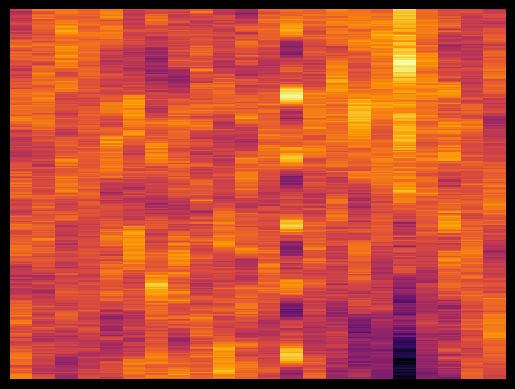

VD: 148.15 Prediction: 20 Probability: tensor(0.9616)
Predicted indices: [0, 20]


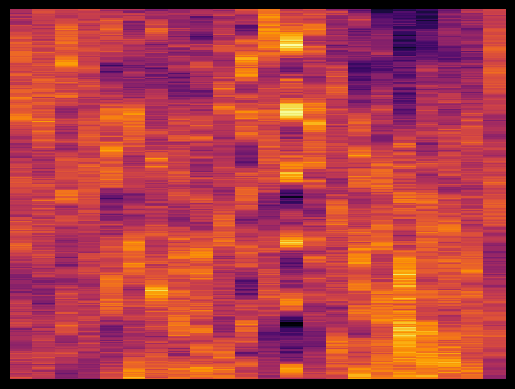

VD: 148.9 Prediction: 13 Probability: tensor(0.9405)
Predicted indices: [12, 13]


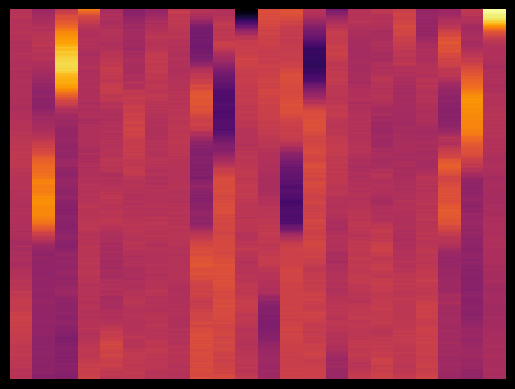

VD: 170.9 Prediction: 12 Probability: tensor(0.9966)
Predicted indices: [12, 13]


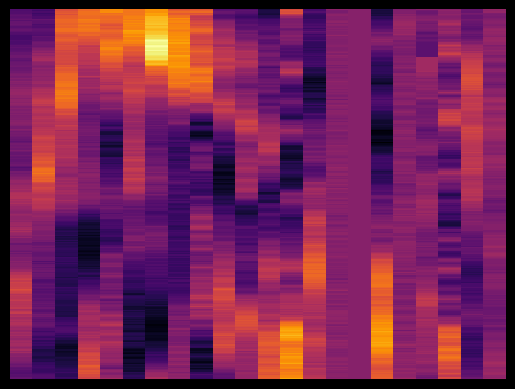

VD: 173.15 Prediction: 4 Probability: tensor(0.9928)
Predicted indices: [3, 4]


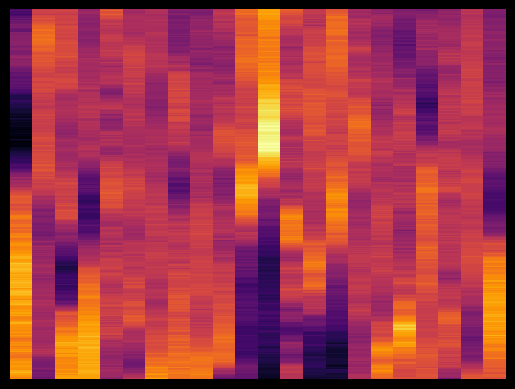

VD: 175.4 Prediction: 2 Probability: tensor(0.9915)
Predicted indices: [1, 2, 3]


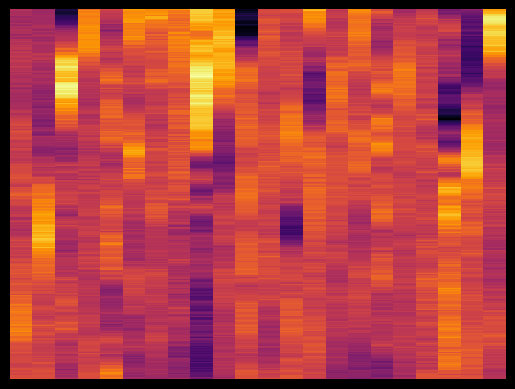

VD: 191.9 Prediction: 12 Probability: tensor(0.9989)
Predicted indices: [12, 13]


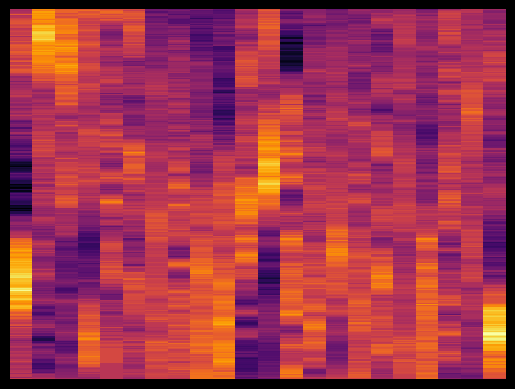

VD: 192.65 Prediction: 12 Probability: tensor(0.9522)
Predicted indices: [12]


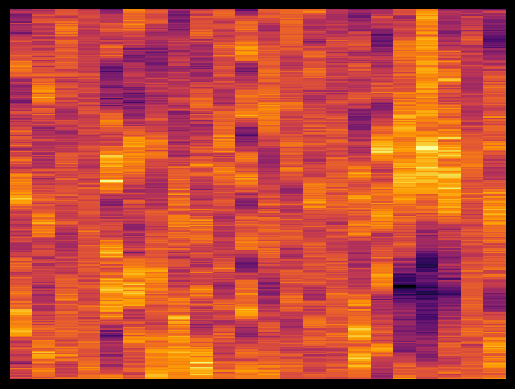

VD: 202.65 Prediction: 18 Probability: tensor(0.9988)
Predicted indices: [18, 19, 20]


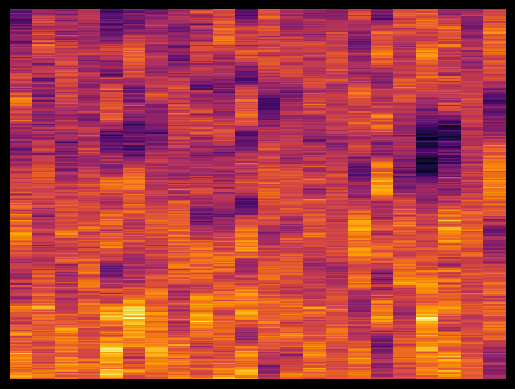

VD: 208.65 Prediction: 20 Probability: tensor(0.9985)
Predicted indices: [19, 20]


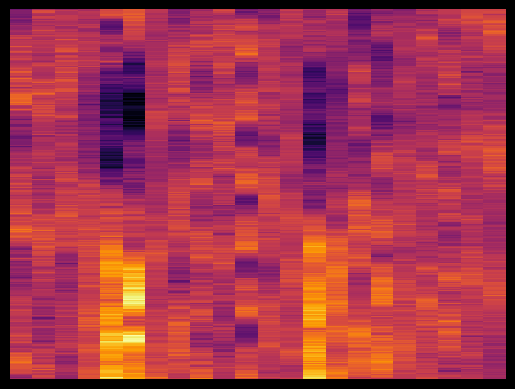

VD: 217.9 Prediction: 5 Probability: tensor(0.9982)
Predicted indices: [5, 6]


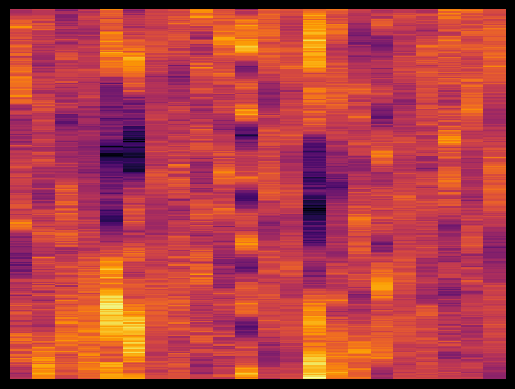

VD: 230.15 Prediction: 5 Probability: tensor(0.9723)
Predicted indices: [5]


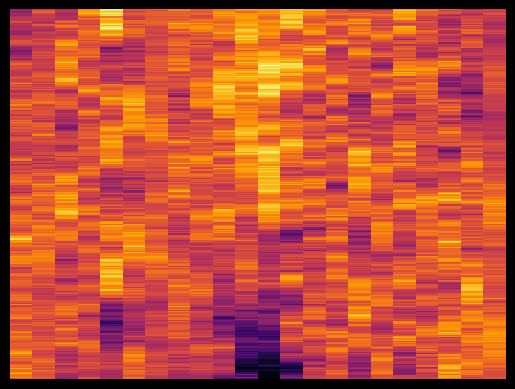

VD: 305.9 Prediction: 12 Probability: tensor(0.9627)
Predicted indices: [11, 12]


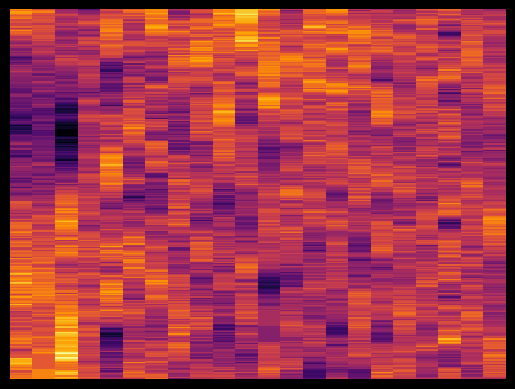

VD: 308.15 Prediction: 1 Probability: tensor(0.9833)
Predicted indices: [1, 2]


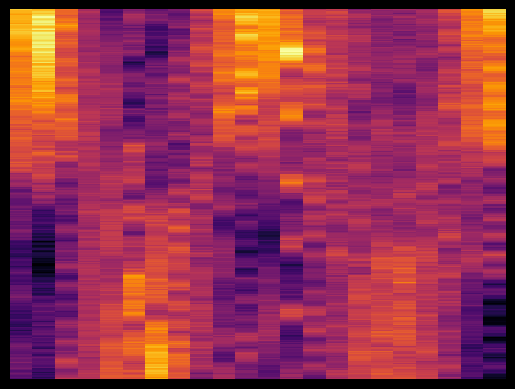

VD: 314.15 Prediction: 1 Probability: tensor(0.9957)
Predicted indices: [0, 1]


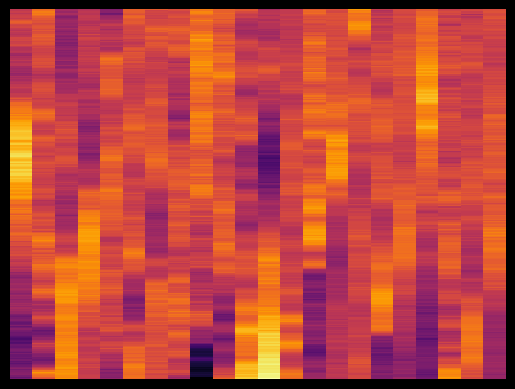

VD: 360.65 Prediction: 11 Probability: tensor(0.9847)
Predicted indices: [11, 12]


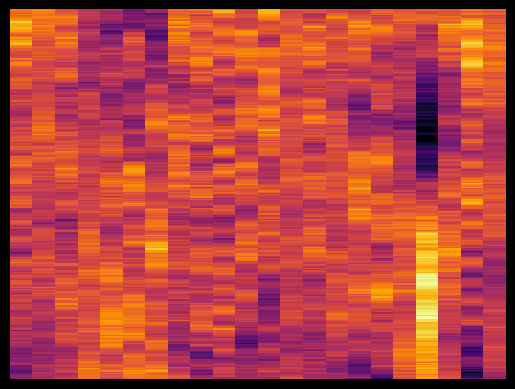

VD: 373.9 Prediction: 19 Probability: tensor(0.9924)
Predicted indices: [18, 19, 20]


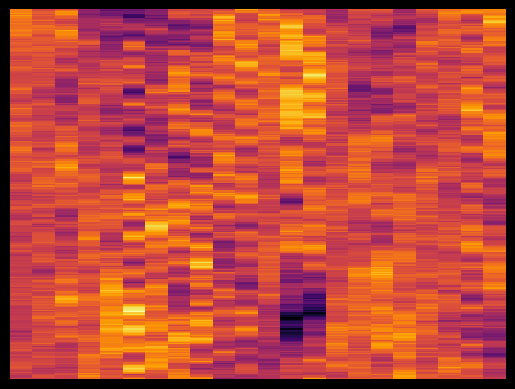

VD: 401.4 Prediction: 14 Probability: tensor(0.9499)
Predicted indices: [14]


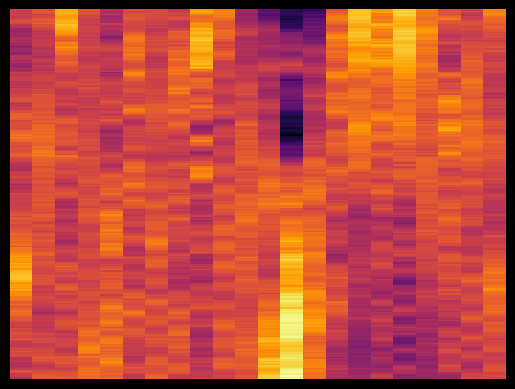

VD: 407.9 Prediction: 13 Probability: tensor(0.9964)
Predicted indices: [12, 13, 14]


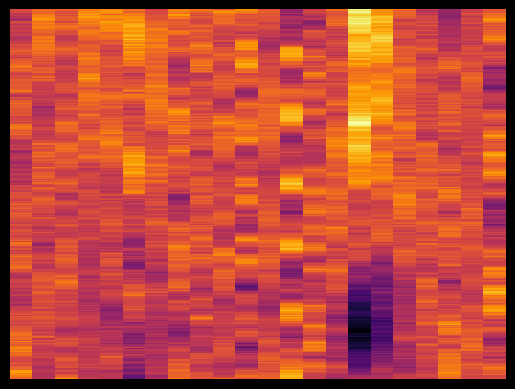

VD: 418.65 Prediction: 17 Probability: tensor(0.9982)
Predicted indices: [16, 17]


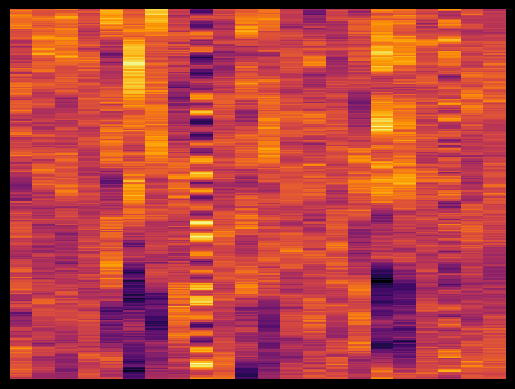

VD: 436.9 Prediction: 18 Probability: tensor(0.9828)
Predicted indices: [18]


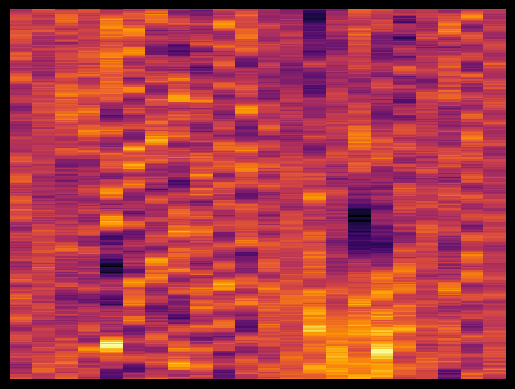

VD: 490.4 Prediction: 16 Probability: tensor(0.9983)
Predicted indices: [15, 16]


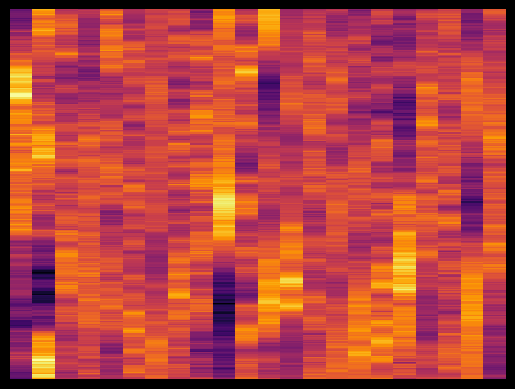

VD: 504.9 Prediction: 10 Probability: tensor(0.9271)
Predicted indices: [10]


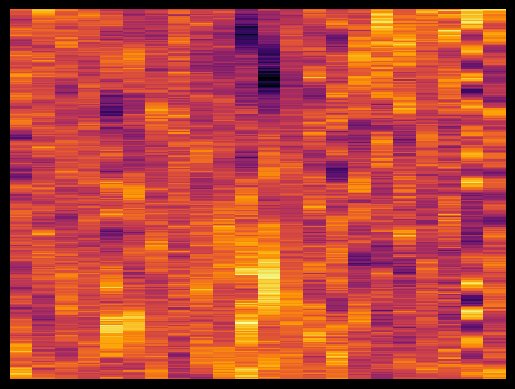

VD: 507.9 Prediction: 12 Probability: tensor(0.9242)
Predicted indices: [11, 12]


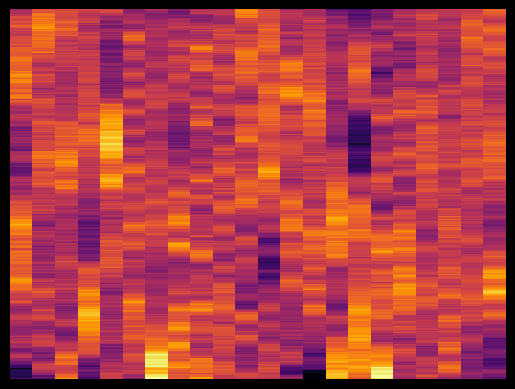

VD: 536.9 Prediction: 15 Probability: tensor(0.9360)
Predicted indices: [15]


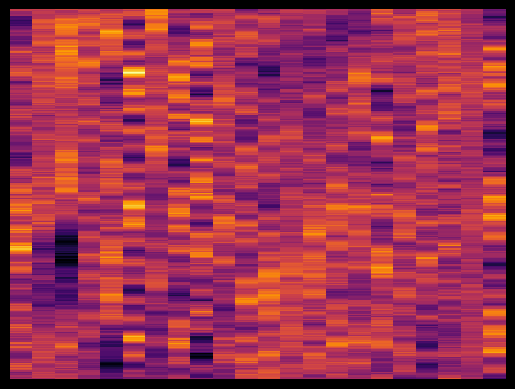

DbHealthCheck.cpp(146): Database service health check complete: Healthy
VD: 541.4 Prediction: 2 Probability: tensor(0.9755)
Predicted indices: [2, 3]


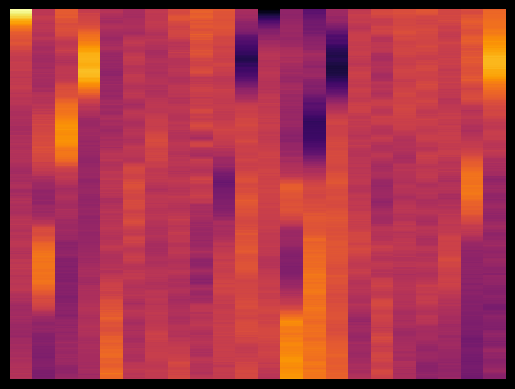

VD: 545.15 Prediction: 13 Probability: tensor(0.9991)
Predicted indices: [12, 13, 14]


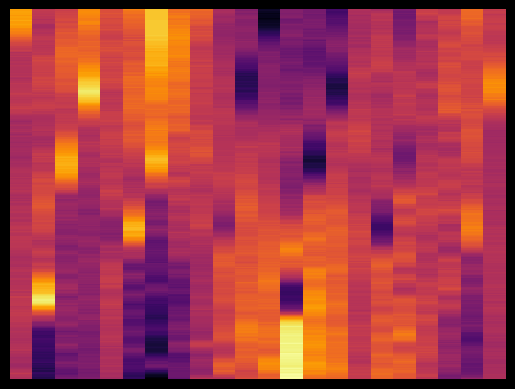

VD: 545.65 Prediction: 14 Probability: tensor(0.9981)
Predicted indices: [12, 13, 14]


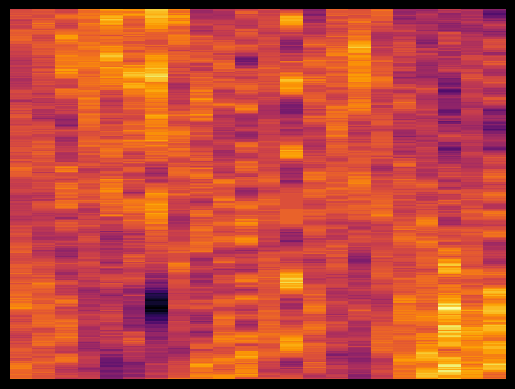

VD: 555.65 Prediction: 7 Probability: tensor(0.9920)
Predicted indices: [7, 8]


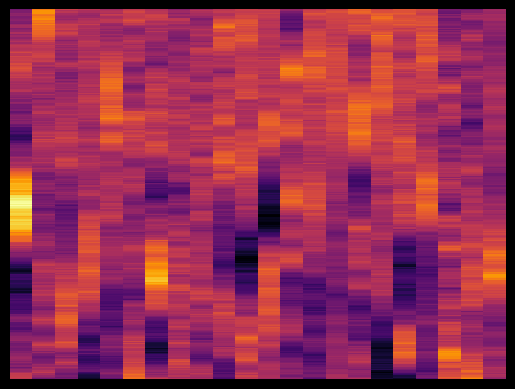

VD: 568.9 Prediction: 12 Probability: tensor(0.9765)
Predicted indices: [12]


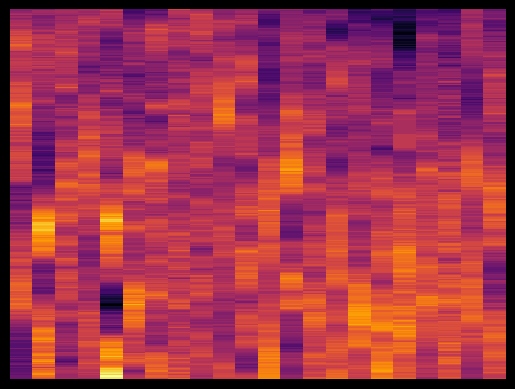

VD: 590.65 Prediction: 1 Probability: tensor(0.9896)
Predicted indices: [0, 1]


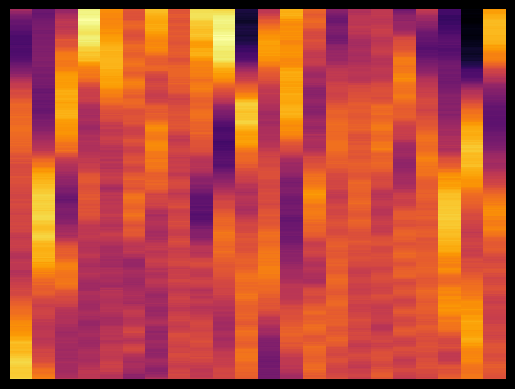

VD: 612.15 Prediction: 1 Probability: tensor(0.9882)
Predicted indices: [0, 1]


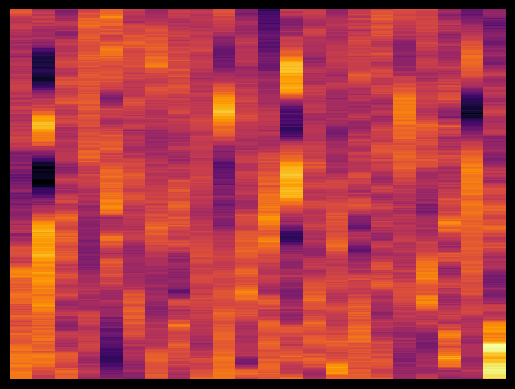

VD: 613.4 Prediction: 1 Probability: tensor(0.9884)
Predicted indices: [0, 1]


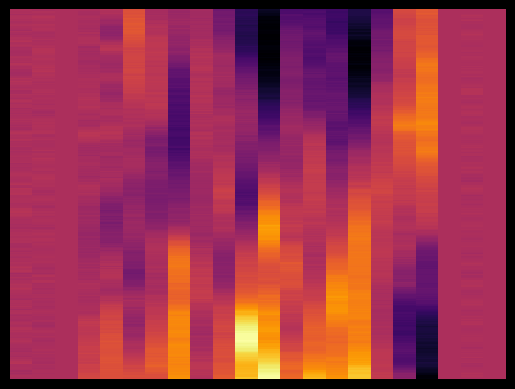

VD: 650.15 Prediction: 20 Probability: tensor(0.9526)
Predicted indices: [20]


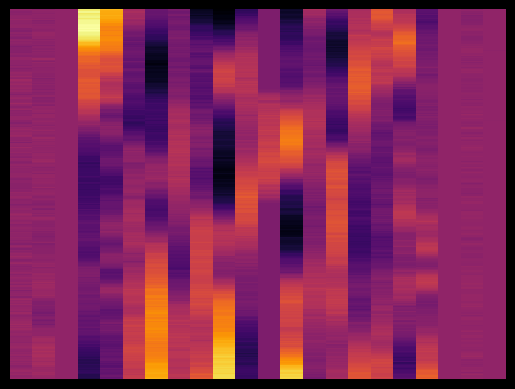

VD: 650.9 Prediction: 11 Probability: tensor(0.9535)
Predicted indices: [11]


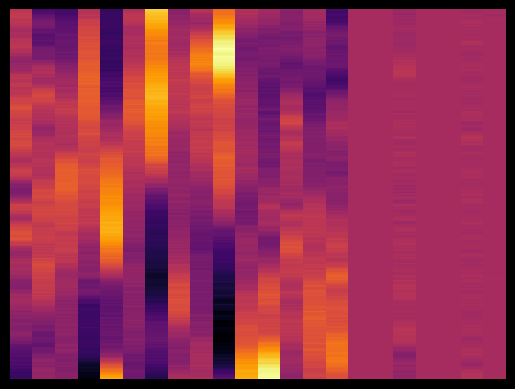

VD: 652.9 Prediction: 6 Probability: tensor(0.9628)
Predicted indices: [6, 7]


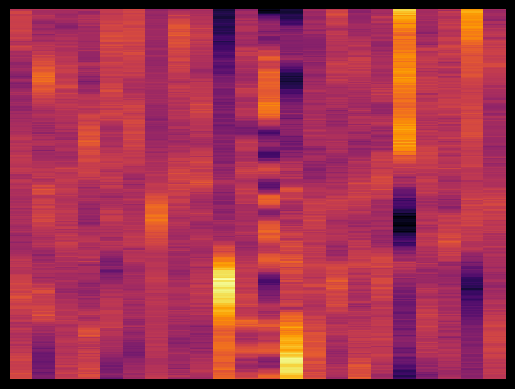

VD: 654.9 Prediction: 20 Probability: tensor(0.9325)
Predicted indices: [19, 20]


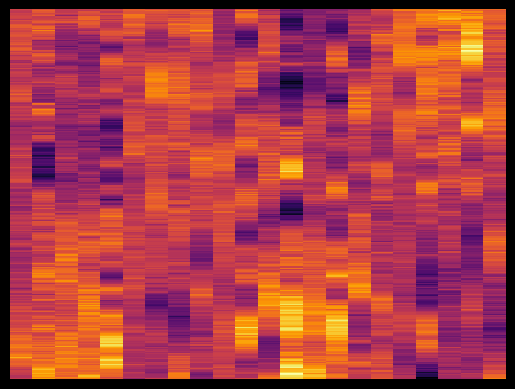

VD: 656.65 Prediction: 12 Probability: tensor(0.9239)
Predicted indices: [12]


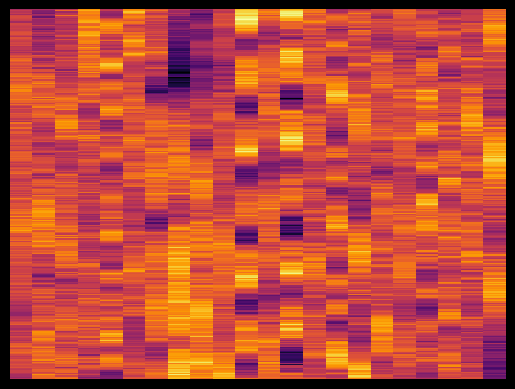

VD: 664.15 Prediction: 8 Probability: tensor(0.9897)
Predicted indices: [8, 9]


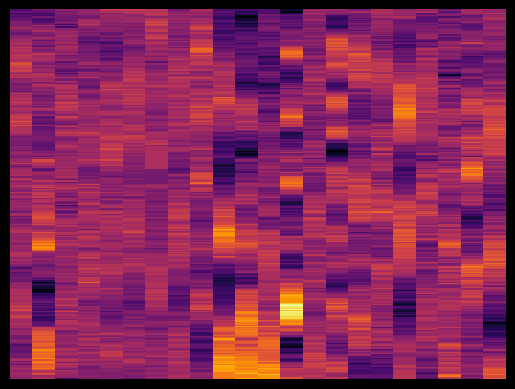

VD: 669.65 Prediction: 11 Probability: tensor(0.9935)
Predicted indices: [10, 11]


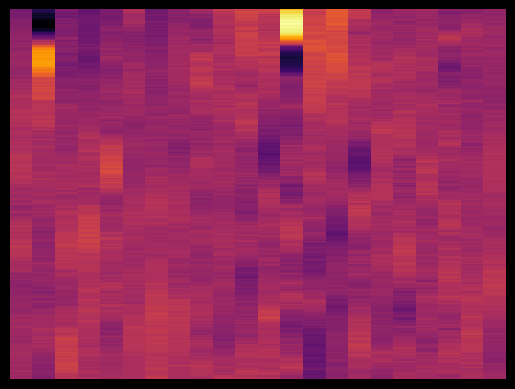

VD: 681.9 Prediction: 14 Probability: tensor(0.9996)
Predicted indices: [12, 13, 14]


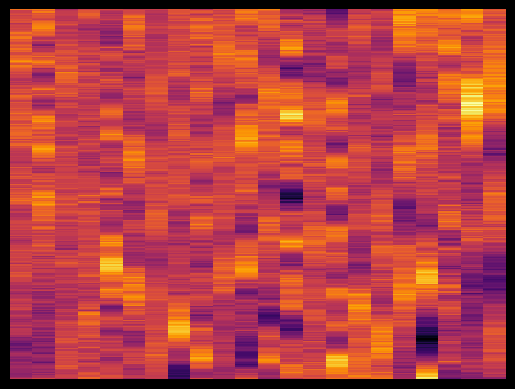

VD: 698.15 Prediction: 20 Probability: tensor(0.9911)
Predicted indices: [20]


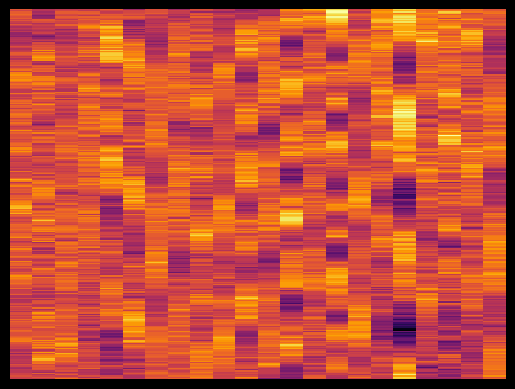

VD: 702.65 Prediction: 20 Probability: tensor(0.9702)
Predicted indices: [0, 20]


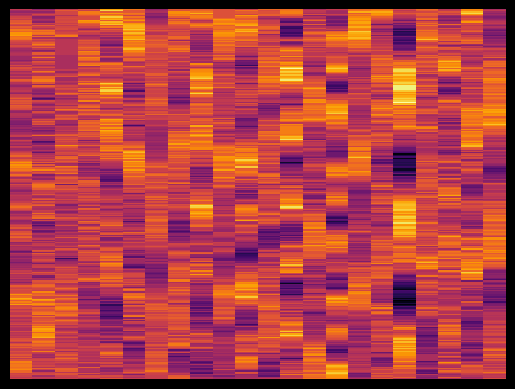

VD: 703.9 Prediction: 20 Probability: tensor(0.9508)
Predicted indices: [0, 20]


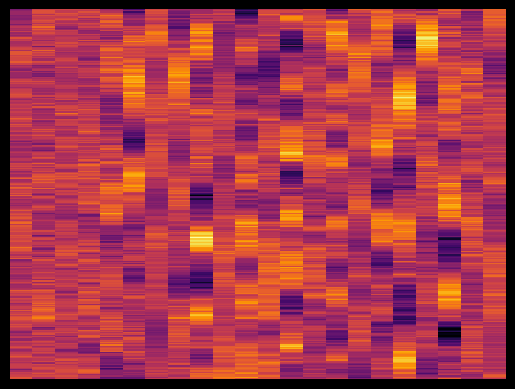

VD: 709.9 Prediction: 7 Probability: tensor(0.9761)
Predicted indices: [6, 7]


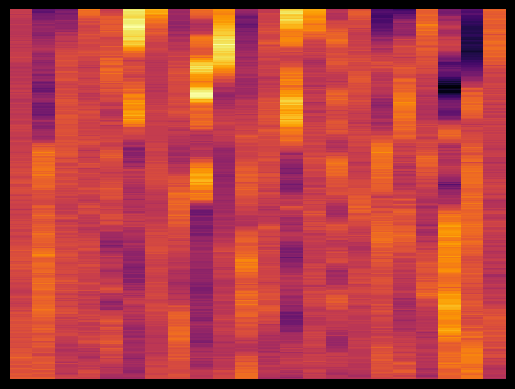

VD: 710.65 Prediction: 20 Probability: tensor(0.9987)
Predicted indices: [0, 20]


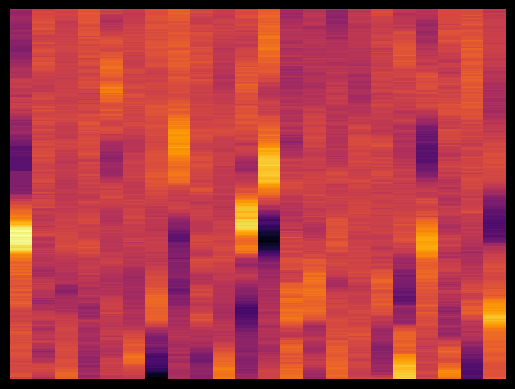

VD: 711.4 Prediction: 20 Probability: tensor(0.9781)
Predicted indices: [0, 20]


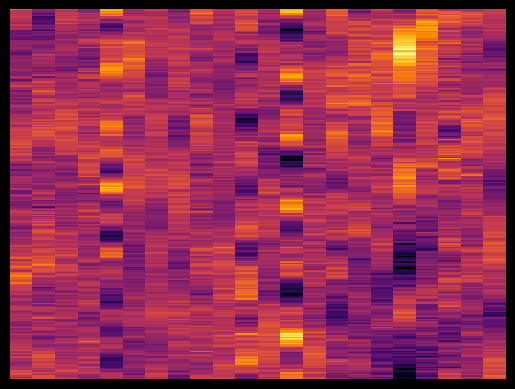

VD: 727.9 Prediction: 20 Probability: tensor(0.9604)
Predicted indices: [0, 20]


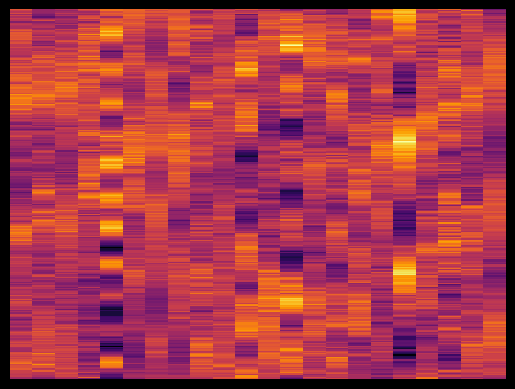

VD: 728.4 Prediction: 20 Probability: tensor(0.9425)
Predicted indices: [20]


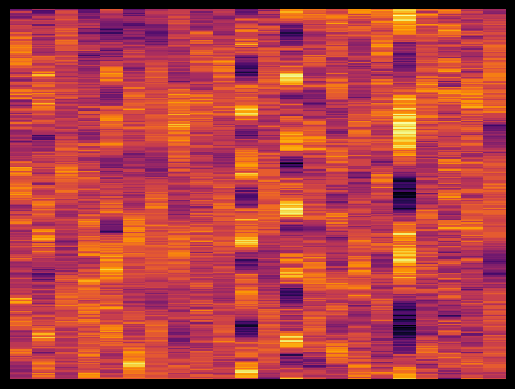

VD: 732.65 Prediction: 20 Probability: tensor(0.9760)
Predicted indices: [20]


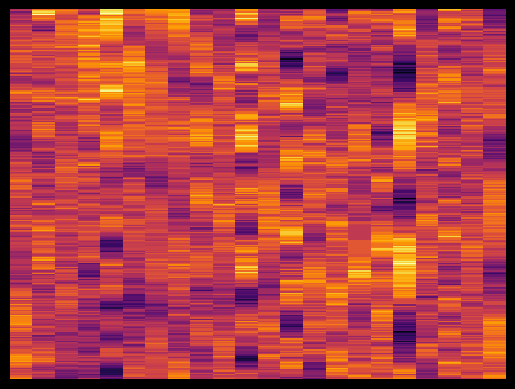

VD: 734.15 Prediction: 19 Probability: tensor(0.9659)
Predicted indices: [18, 19]


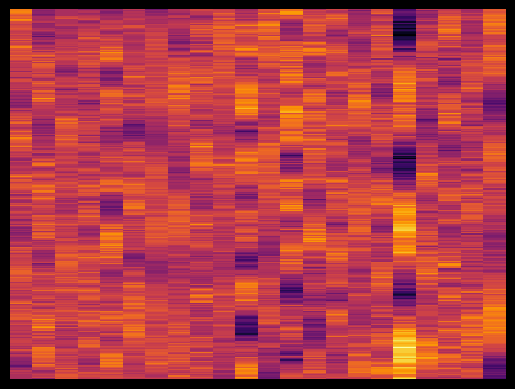

VD: 734.65 Prediction: 20 Probability: tensor(0.9086)
Predicted indices: [20]


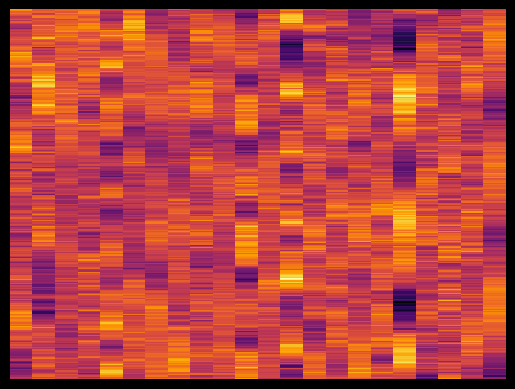

VD: 735.4 Prediction: 20 Probability: tensor(0.9763)
Predicted indices: [0, 20]


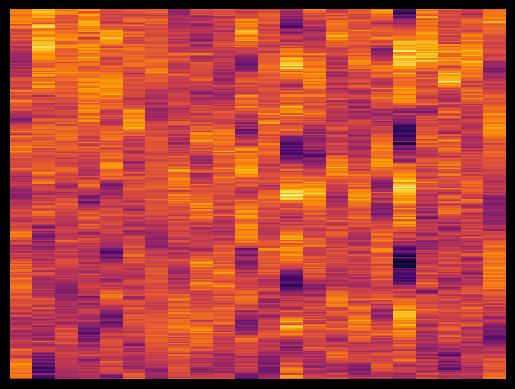

VD: 736.65 Prediction: 20 Probability: tensor(0.9901)
Predicted indices: [19, 20]


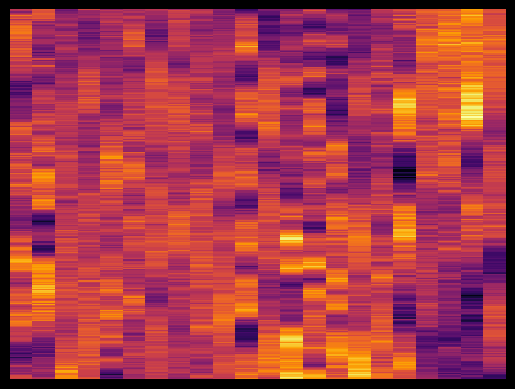

VD: 738.4 Prediction: 20 Probability: tensor(0.9751)
Predicted indices: [0, 20]


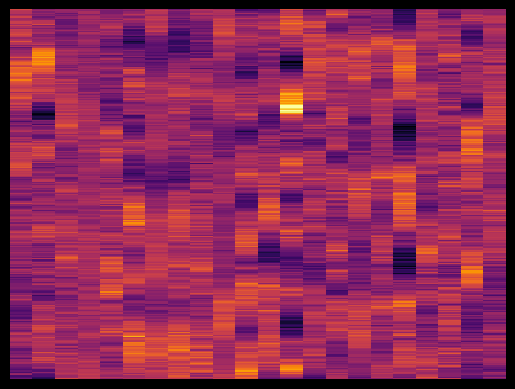

VD: 752.15 Prediction: 20 Probability: tensor(0.9296)
Predicted indices: [20]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


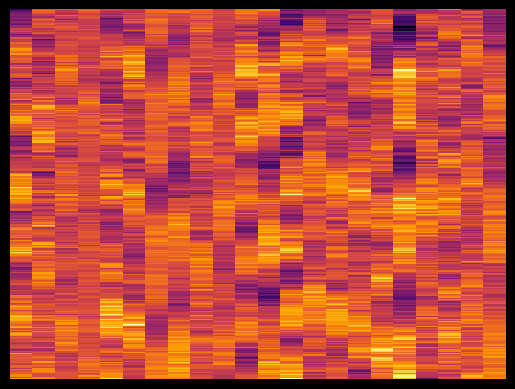

VD: 758.65 Prediction: 20 Probability: tensor(0.9248)
Predicted indices: [20]


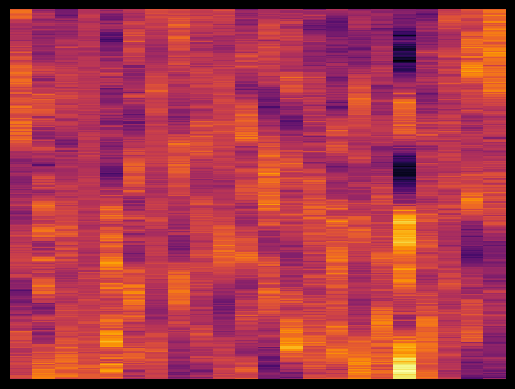

VD: 778.65 Prediction: 20 Probability: tensor(0.9176)
Predicted indices: [20]


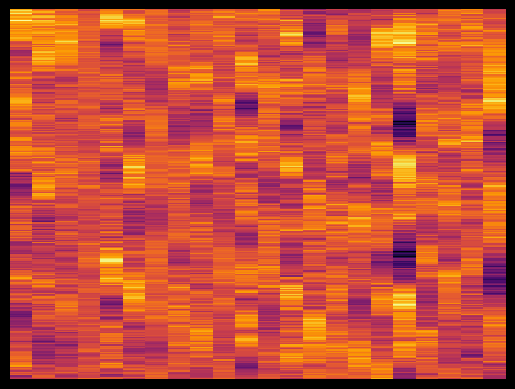

VD: 787.4 Prediction: 17 Probability: tensor(0.9659)
Predicted indices: [17, 18]


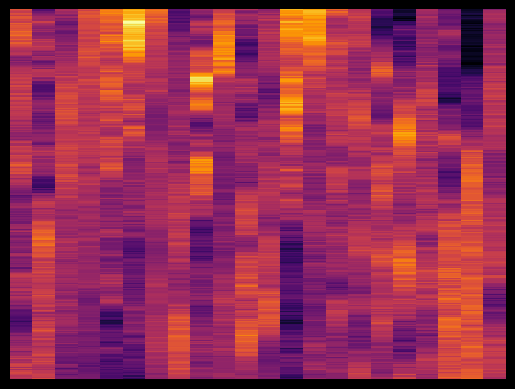

VD: 790.4 Prediction: 20 Probability: tensor(0.9987)
Predicted indices: [0, 20]


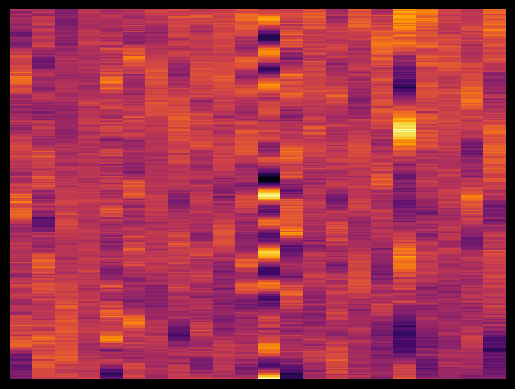

VD: 791.4 Prediction: 18 Probability: tensor(0.9987)
Predicted indices: [18, 19]


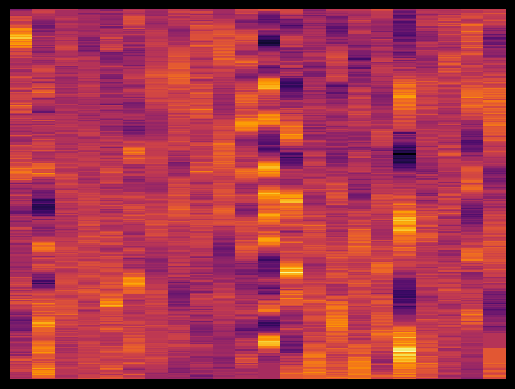

VD: 791.9 Prediction: 20 Probability: tensor(0.9611)
Predicted indices: [0, 20]


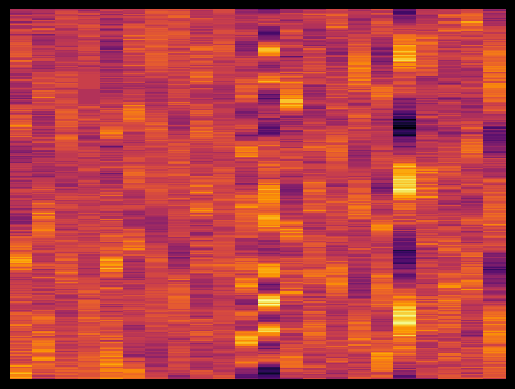

VD: 792.4 Prediction: 18 Probability: tensor(0.9979)
Predicted indices: [18, 19]


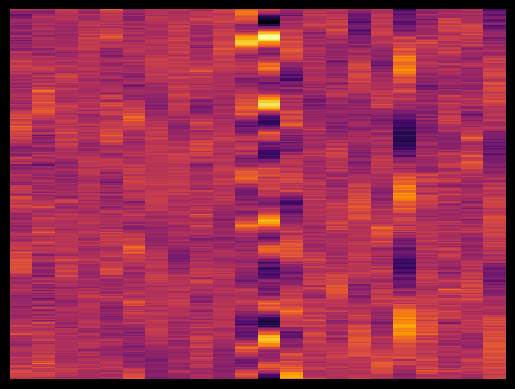

VD: 793.15 Prediction: 20 Probability: tensor(0.9210)
Predicted indices: [20]


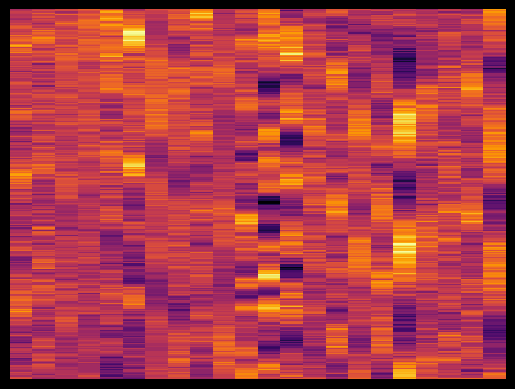

VD: 794.15 Prediction: 20 Probability: tensor(0.9412)
Predicted indices: [20]


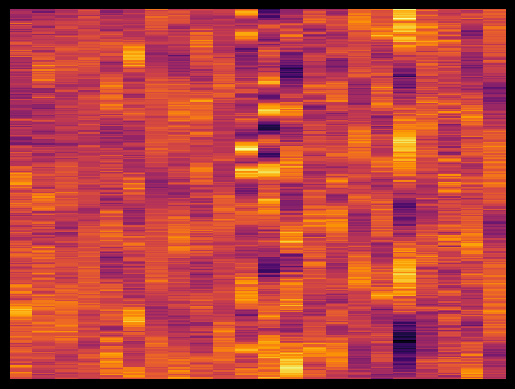

VD: 796.4 Prediction: 20 Probability: tensor(0.9669)
Predicted indices: [0, 20]


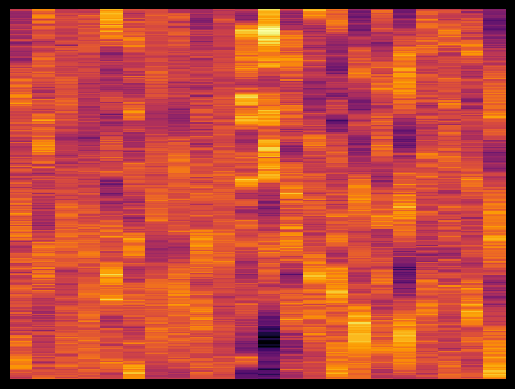

VD: 798.15 Prediction: 12 Probability: tensor(0.9948)
Predicted indices: [11, 12, 13]


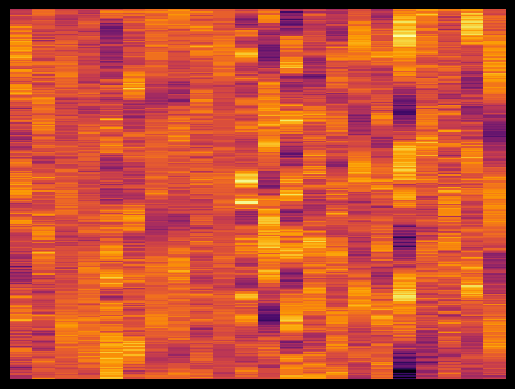

VD: 800.15 Prediction: 20 Probability: tensor(0.9589)
Predicted indices: [0, 20]


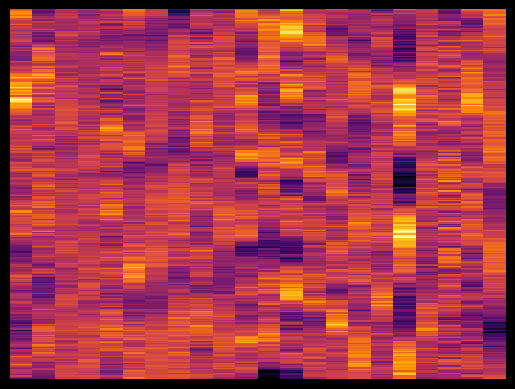

VD: 802.65 Prediction: 19 Probability: tensor(0.9835)
Predicted indices: [18, 19, 20]


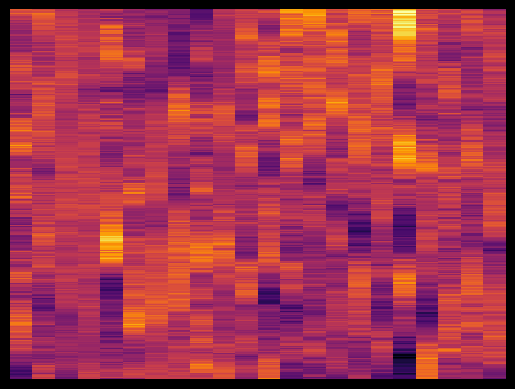

VD: 803.65 Prediction: 19 Probability: tensor(0.9603)
Predicted indices: [18, 19]


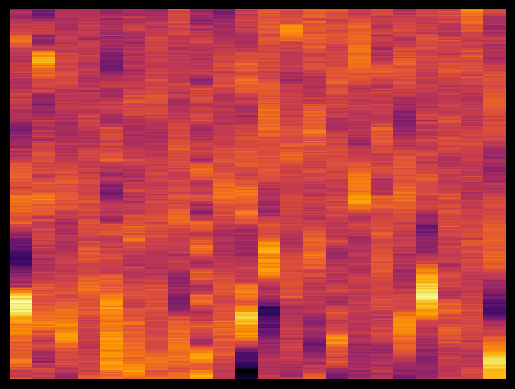

VD: 804.65 Prediction: 20 Probability: tensor(0.9575)
Predicted indices: [20]


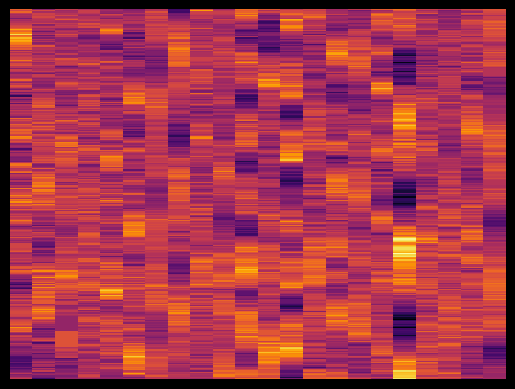

VD: 815.65 Prediction: 20 Probability: tensor(0.9336)
Predicted indices: [0, 20]


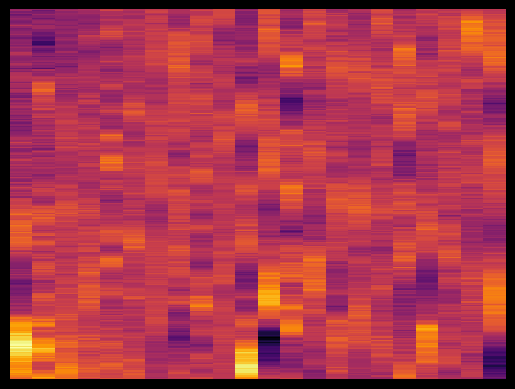

VD: 817.9 Prediction: 12 Probability: tensor(0.9268)
Predicted indices: [12]


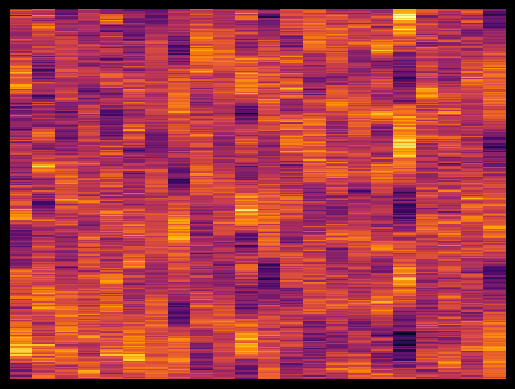

VD: 826.65 Prediction: 19 Probability: tensor(0.9417)
Predicted indices: [18, 19]


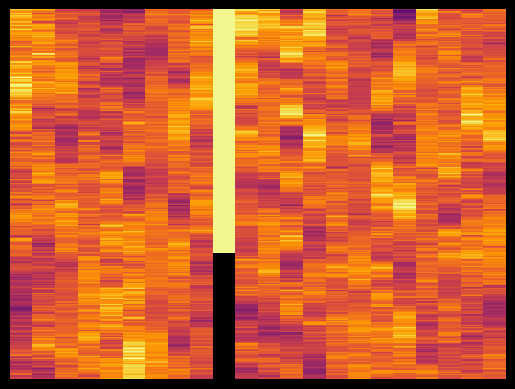

VD: 829.65 Prediction: 10 Probability: tensor(0.9425)
Predicted indices: [9, 10]


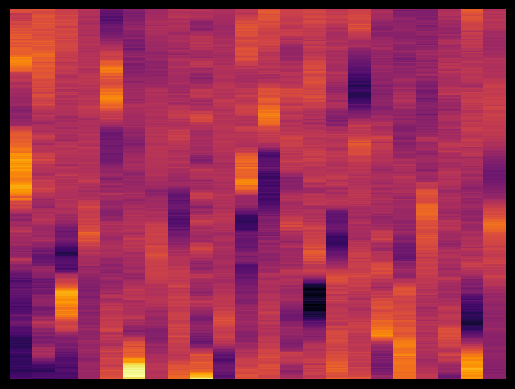

VD: 831.15 Prediction: 12 Probability: tensor(0.9480)
Predicted indices: [12]


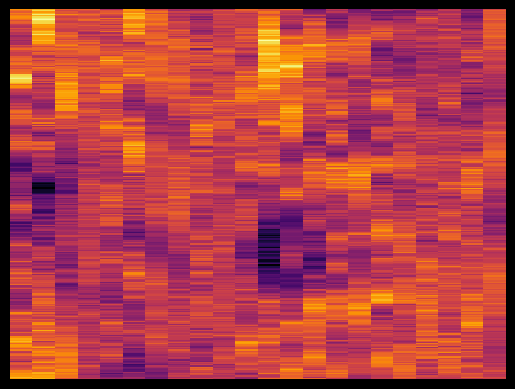

VD: 835.65 Prediction: 12 Probability: tensor(0.9844)
Predicted indices: [12, 13]


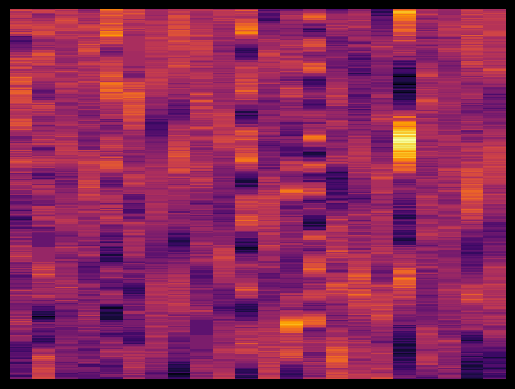

VD: 844.9 Prediction: 18 Probability: tensor(0.9896)
Predicted indices: [18, 19]


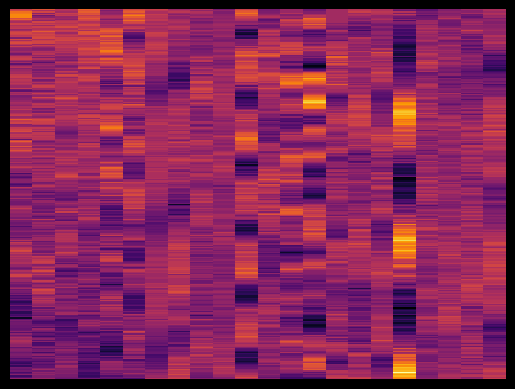

VD: 846.15 Prediction: 20 Probability: tensor(0.9840)
Predicted indices: [19, 20]


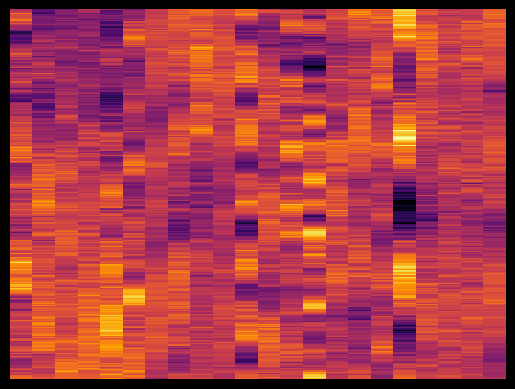

VD: 849.15 Prediction: 20 Probability: tensor(0.9826)
Predicted indices: [19, 20]


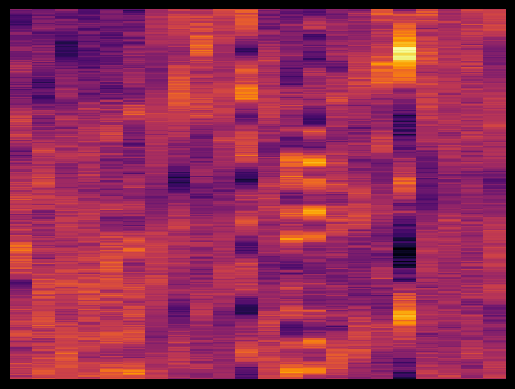

VD: 853.9 Prediction: 18 Probability: tensor(0.9177)
Predicted indices: [18]


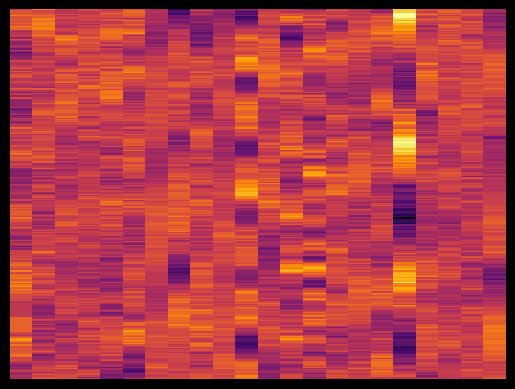

VD: 854.4 Prediction: 20 Probability: tensor(0.9309)
Predicted indices: [20]


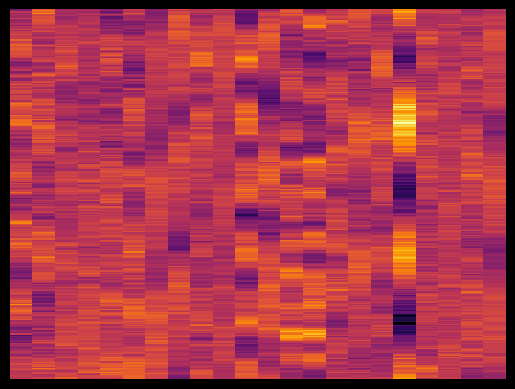

VD: 856.4 Prediction: 19 Probability: tensor(0.9905)
Predicted indices: [18, 19, 20]


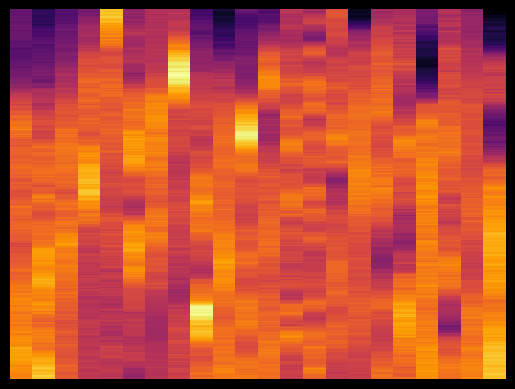

VD: 857.4 Prediction: 20 Probability: tensor(0.9747)
Predicted indices: [19, 20]


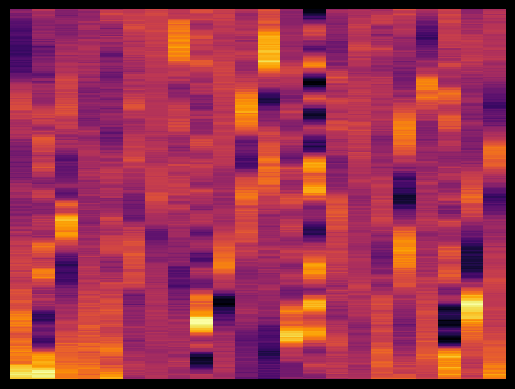

VD: 871.15 Prediction: 20 Probability: tensor(0.9987)
Predicted indices: [0, 20]


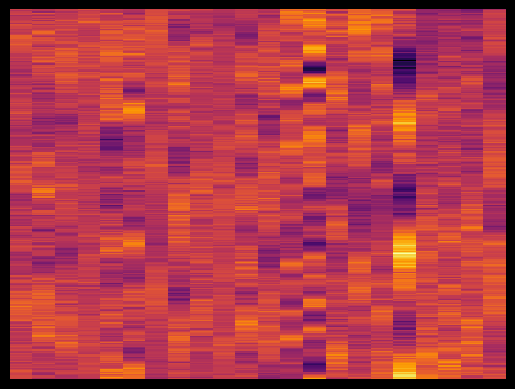

VD: 875.65 Prediction: 20 Probability: tensor(0.9745)
Predicted indices: [19, 20]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


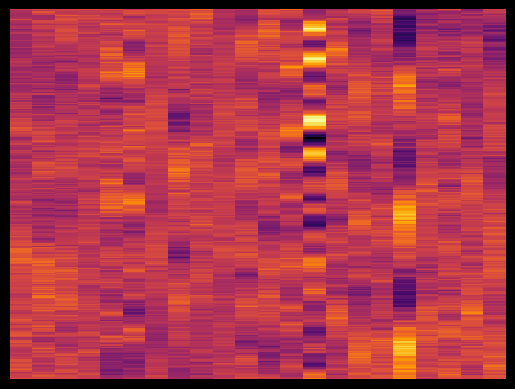

VD: 876.9 Prediction: 20 Probability: tensor(0.9460)
Predicted indices: [19, 20]


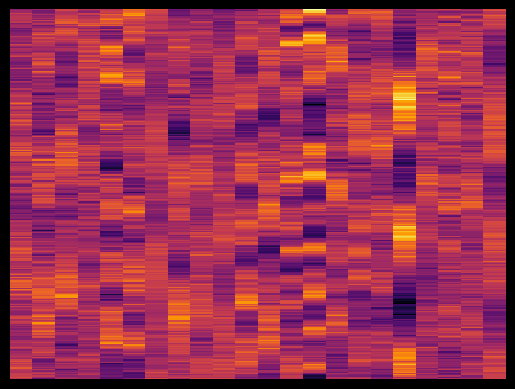

VD: 879.15 Prediction: 20 Probability: tensor(0.9291)
Predicted indices: [20]


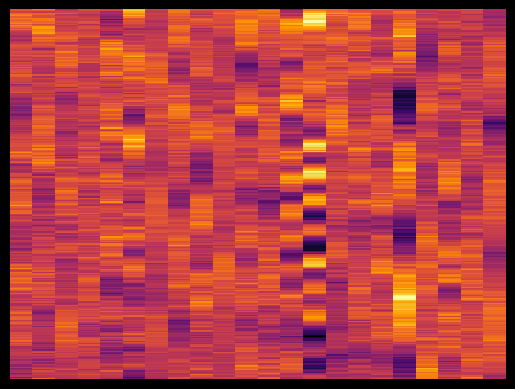

VD: 883.15 Prediction: 19 Probability: tensor(0.9884)
Predicted indices: [18, 19, 20]


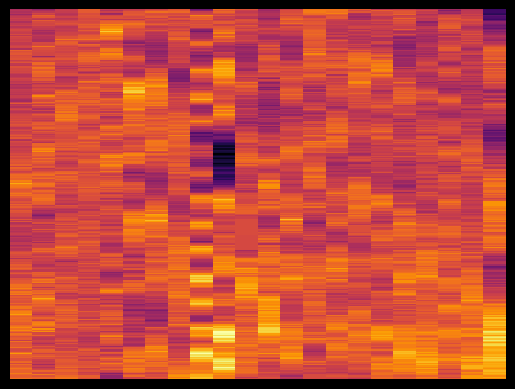

VD: 886.15 Prediction: 10 Probability: tensor(0.9586)
Predicted indices: [10]


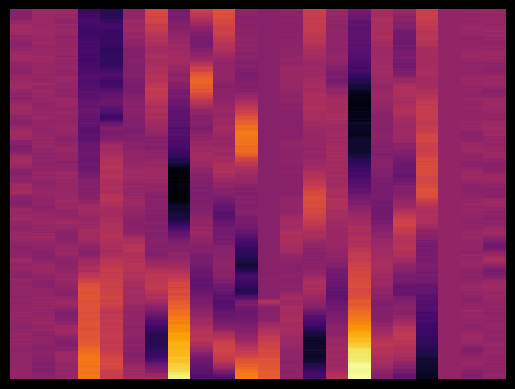

VD: 892.65 Prediction: 6 Probability: tensor(0.9532)
Predicted indices: [6]


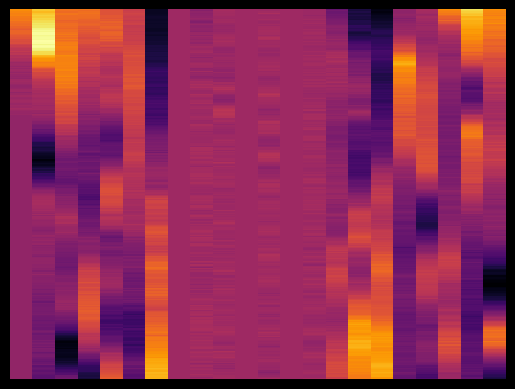

VD: 896.9 Prediction: 18 Probability: tensor(0.9105)
Predicted indices: [18]


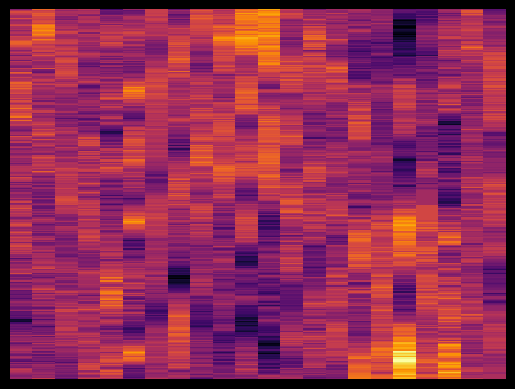

VD: 899.4 Prediction: 20 Probability: tensor(0.9562)
Predicted indices: [20]


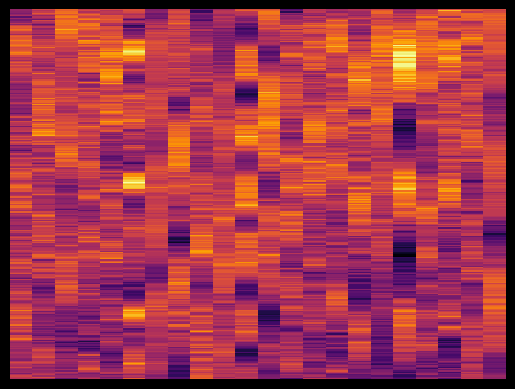

VD: 899.9 Prediction: 19 Probability: tensor(0.9871)
Predicted indices: [18, 19]


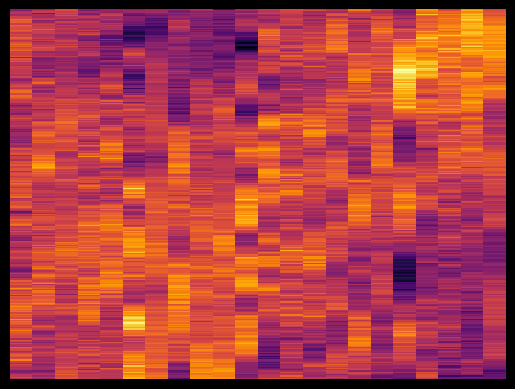

VD: 904.9 Prediction: 20 Probability: tensor(0.9901)
Predicted indices: [0, 20]


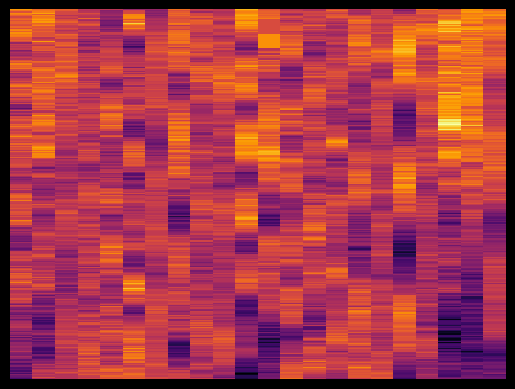

VD: 906.9 Prediction: 20 Probability: tensor(0.9856)
Predicted indices: [0, 20]


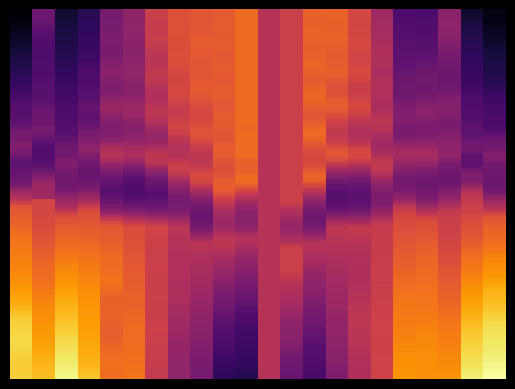

VD: 910.15 Prediction: 1 Probability: tensor(0.9930)
Predicted indices: [0, 1]


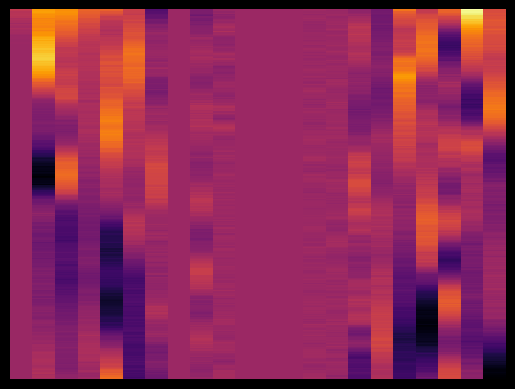

VD: 910.65 Prediction: 18 Probability: tensor(0.9998)
Predicted indices: [18, 19]


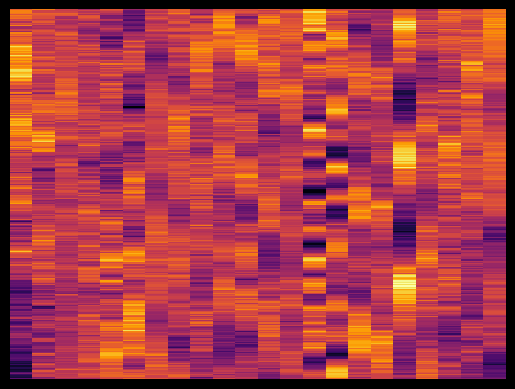

VD: 917.4 Prediction: 20 Probability: tensor(0.9809)
Predicted indices: [0, 20]


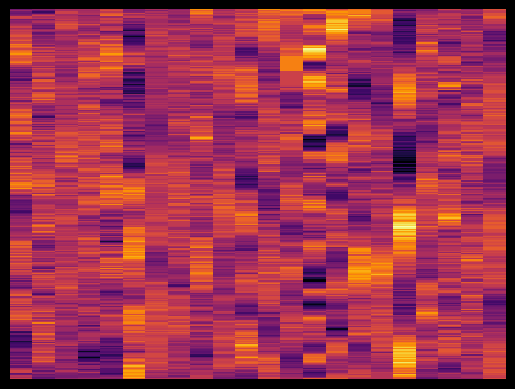

VD: 919.9 Prediction: 18 Probability: tensor(0.9280)
Predicted indices: [18]


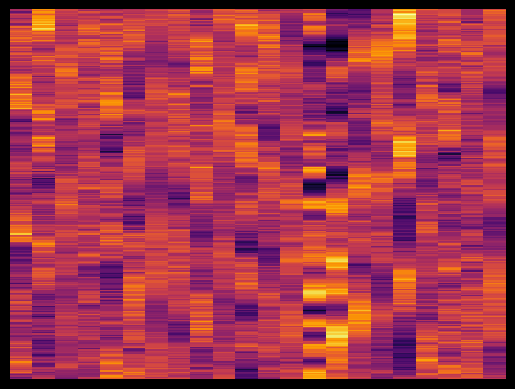

VD: 920.9 Prediction: 16 Probability: tensor(0.9659)
Predicted indices: [16, 17]


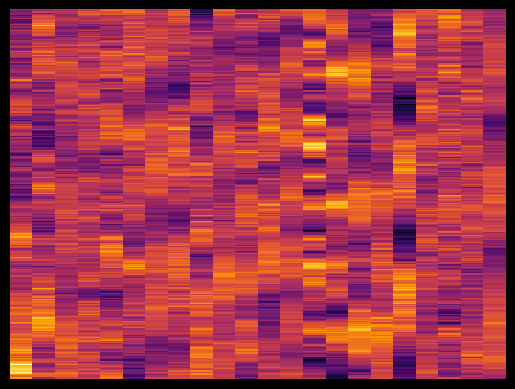

VD: 923.9 Prediction: 20 Probability: tensor(0.9465)
Predicted indices: [20]


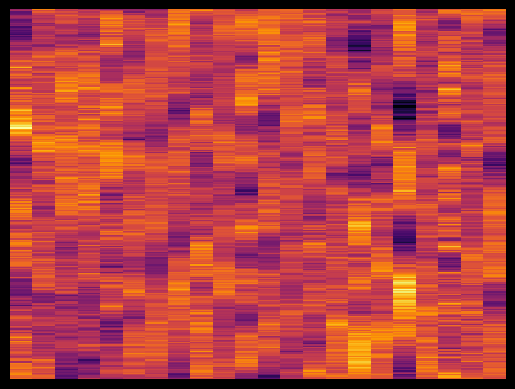

VD: 931.9 Prediction: 18 Probability: tensor(0.9733)
Predicted indices: [17, 18]


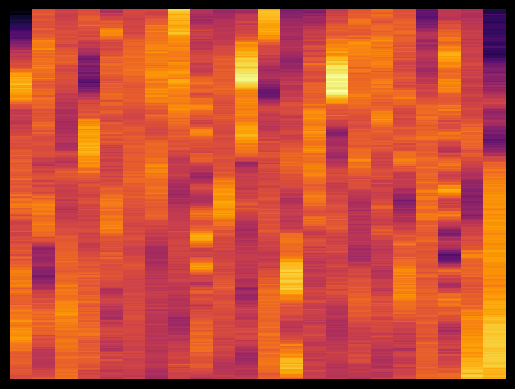

VD: 941.65 Prediction: 1 Probability: tensor(0.9946)
Predicted indices: [0, 1]


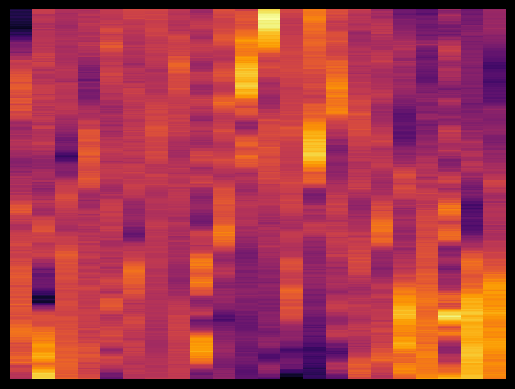

VD: 942.15 Prediction: 1 Probability: tensor(0.9982)
Predicted indices: [1, 2]


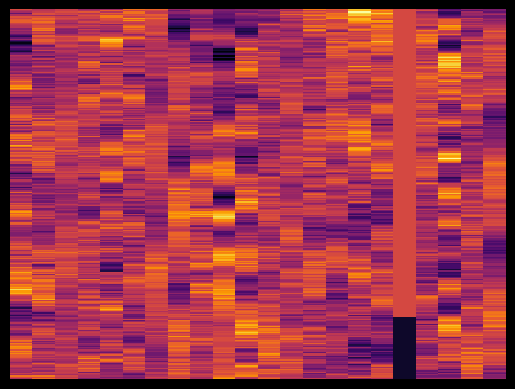

VD: 943.65 Prediction: 20 Probability: tensor(0.9939)
Predicted indices: [19, 20]


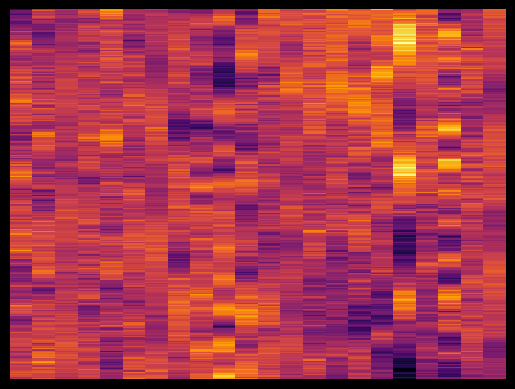

VD: 944.9 Prediction: 20 Probability: tensor(0.9284)
Predicted indices: [0, 20]


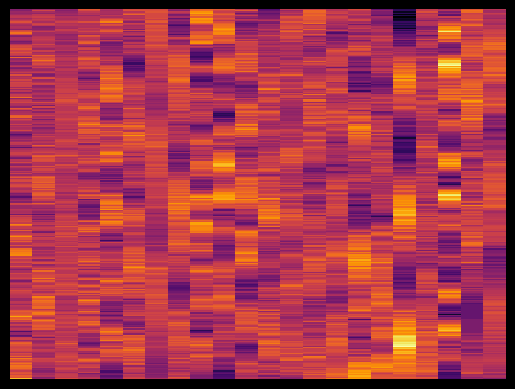

VD: 947.9 Prediction: 18 Probability: tensor(0.9704)
Predicted indices: [18, 19]


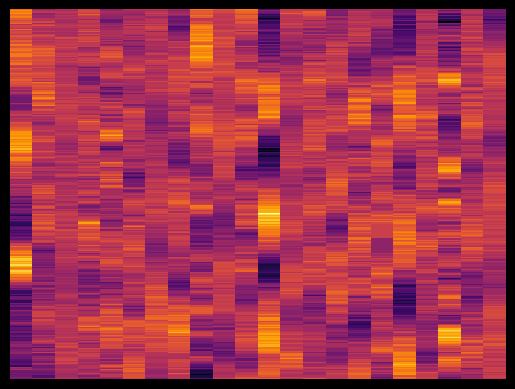

VD: 953.65 Prediction: 12 Probability: tensor(0.9086)
Predicted indices: [12]


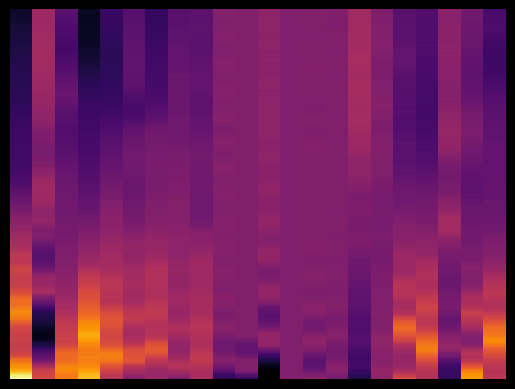

VD: 955.4 Prediction: 1 Probability: tensor(0.9947)
Predicted indices: [1, 2]


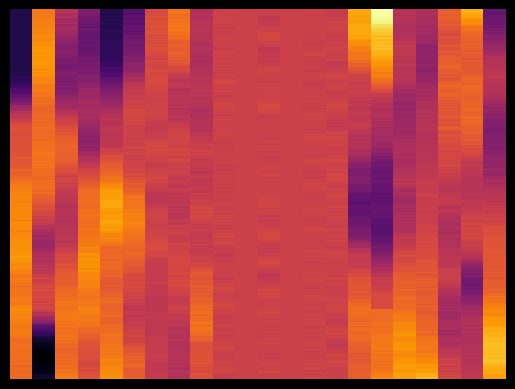

VD: 955.9 Prediction: 2 Probability: tensor(0.9601)
Predicted indices: [2, 3]


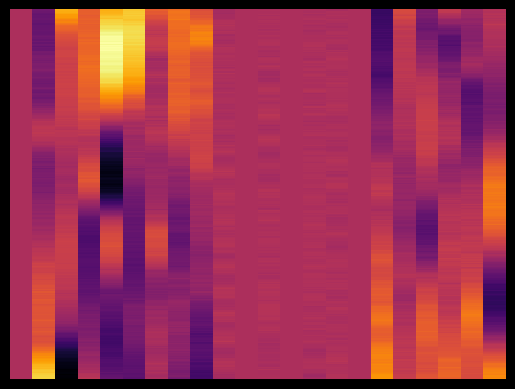

VD: 956.65 Prediction: 18 Probability: tensor(0.9132)
Predicted indices: [18]


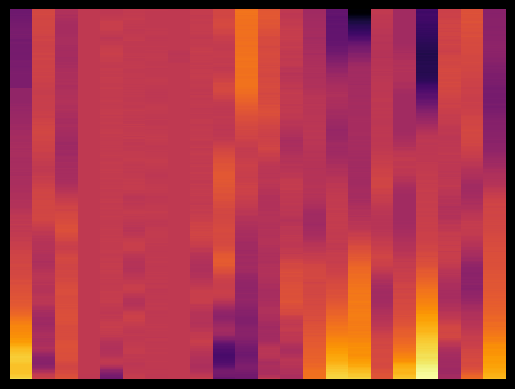

VD: 958.65 Prediction: 20 Probability: tensor(0.9505)
Predicted indices: [0, 20]


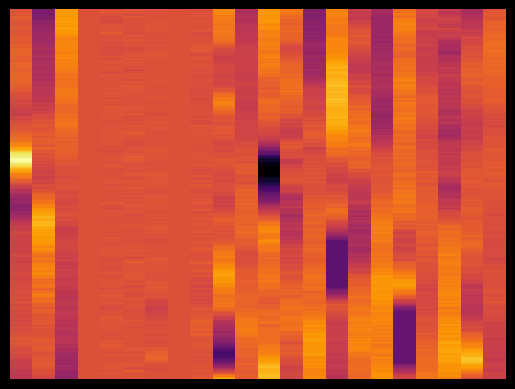

VD: 959.15 Prediction: 12 Probability: tensor(0.9960)
Predicted indices: [12, 13]
DbHealthCheck.cpp(146): Database service health check complete: Healthy


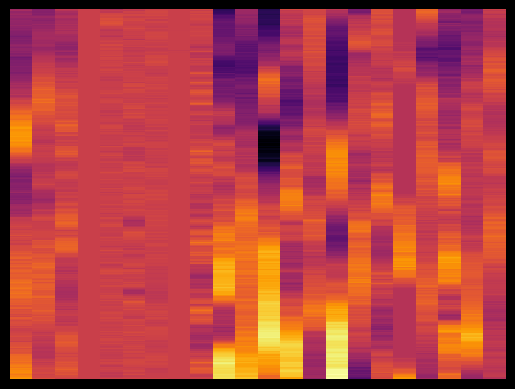

VD: 959.65 Prediction: 11 Probability: tensor(0.9742)
Predicted indices: [10, 11]


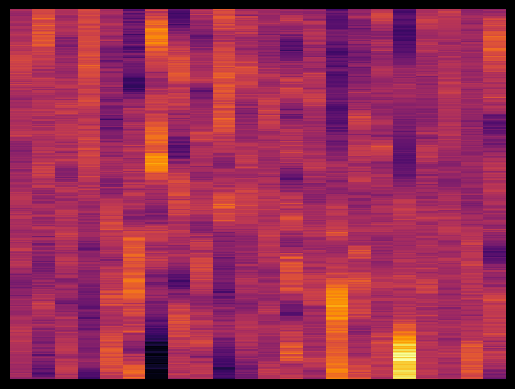

VD: 961.15 Prediction: 6 Probability: tensor(0.9692)
Predicted indices: [6, 7]


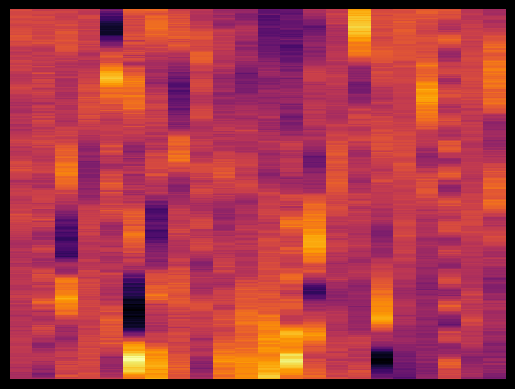

VD: 973.9 Prediction: 5 Probability: tensor(0.9828)
Predicted indices: [5, 6]


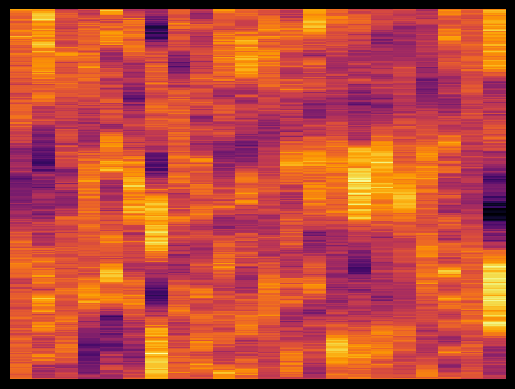

VD: 977.9 Prediction: 6 Probability: tensor(0.9919)
Predicted indices: [5, 6]


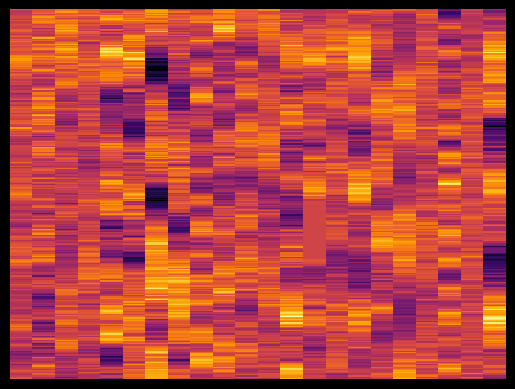

VD: 981.65 Prediction: 7 Probability: tensor(0.9841)
Predicted indices: [6, 7]


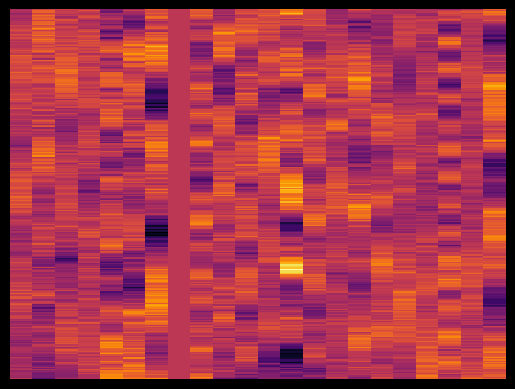

VD: 984.65 Prediction: 7 Probability: tensor(0.9993)
Predicted indices: [6, 7, 8]


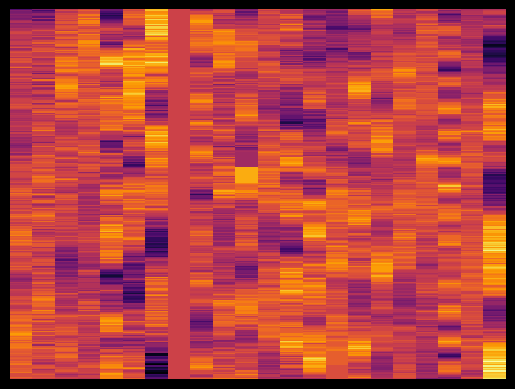

VD: 985.4 Prediction: 6 Probability: tensor(0.9359)
Predicted indices: [6, 7]


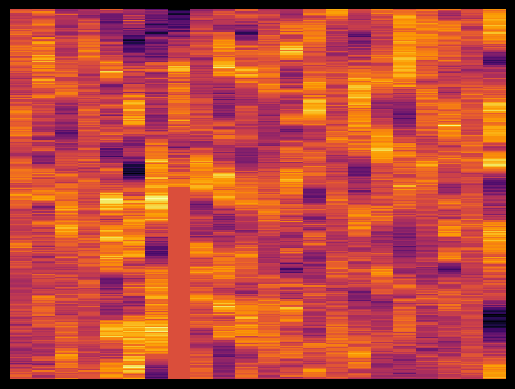

VD: 986.15 Prediction: 7 Probability: tensor(0.9964)
Predicted indices: [6, 7, 8]


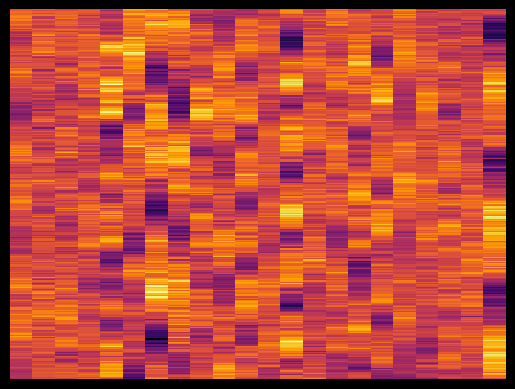

VD: 991.65 Prediction: 7 Probability: tensor(0.9967)
Predicted indices: [6, 7]


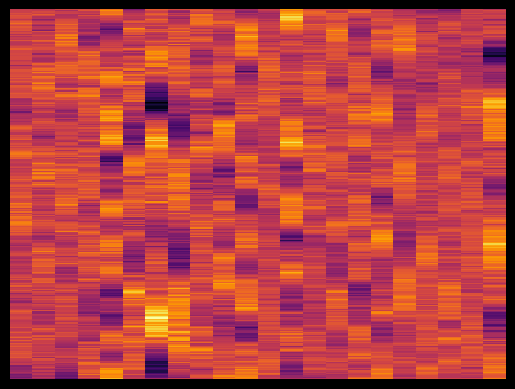

VD: 994.65 Prediction: 7 Probability: tensor(0.9733)
Predicted indices: [7]


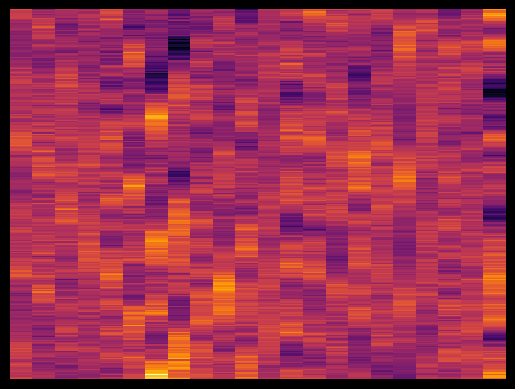

VD: 1000.65 Prediction: 7 Probability: tensor(0.9977)
Predicted indices: [6, 7, 8]


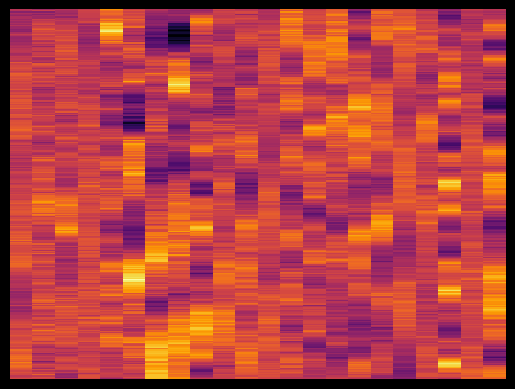

VD: 1009.15 Prediction: 6 Probability: tensor(0.9993)
Predicted indices: [5, 6, 7]


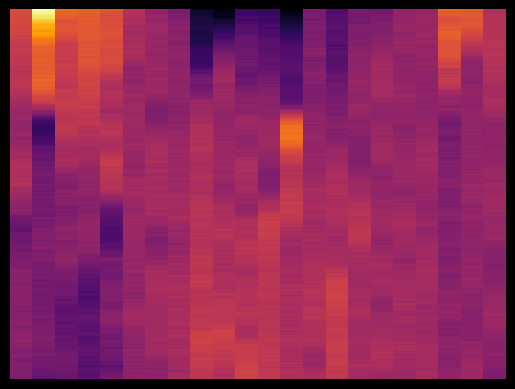

VD: 1023.15 Prediction: 1 Probability: tensor(0.9892)
Predicted indices: [1, 2]


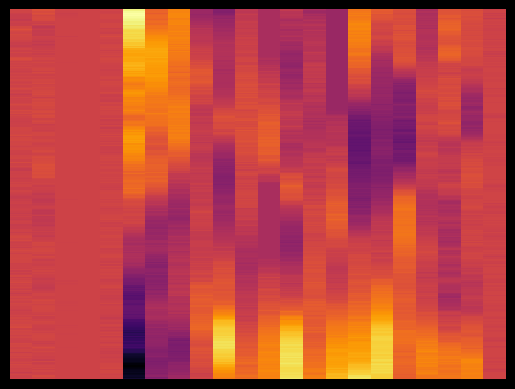

VD: 1024.65 Prediction: 5 Probability: tensor(0.9967)
Predicted indices: [4, 5, 6]


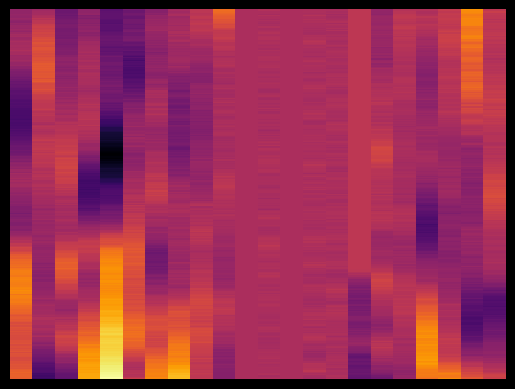

VD: 1029.9 Prediction: 4 Probability: tensor(0.9705)
Predicted indices: [4]


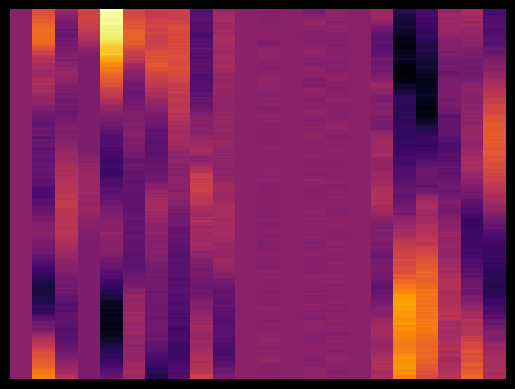

VD: 1030.65 Prediction: 18 Probability: tensor(0.9130)
Predicted indices: [18]


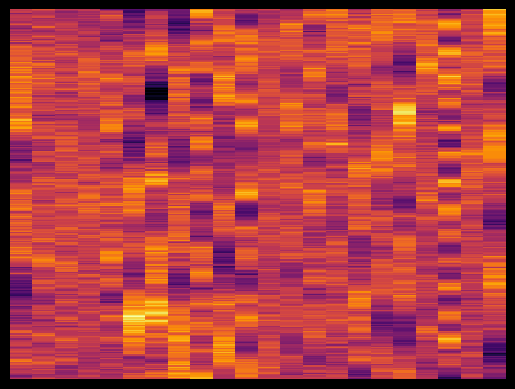

VD: 1040.15 Prediction: 7 Probability: tensor(0.9832)
Predicted indices: [6, 7]


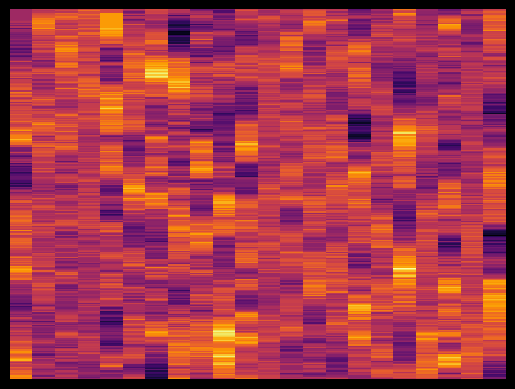

VD: 1042.4 Prediction: 20 Probability: tensor(0.9517)
Predicted indices: [20]


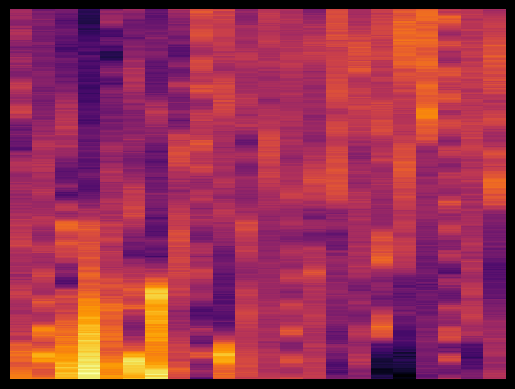

VD: 1046.15 Prediction: 5 Probability: tensor(0.9273)
Predicted indices: [5]


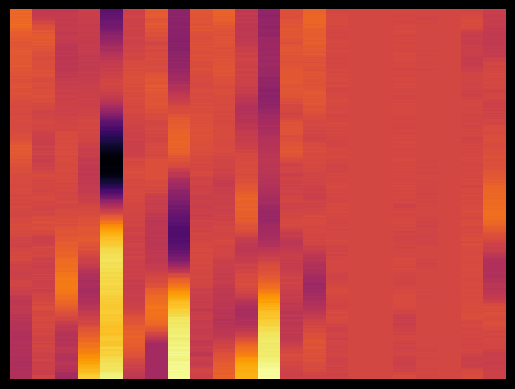

VD: 1078.9 Prediction: 5 Probability: tensor(0.9998)
Predicted indices: [4, 5, 6]


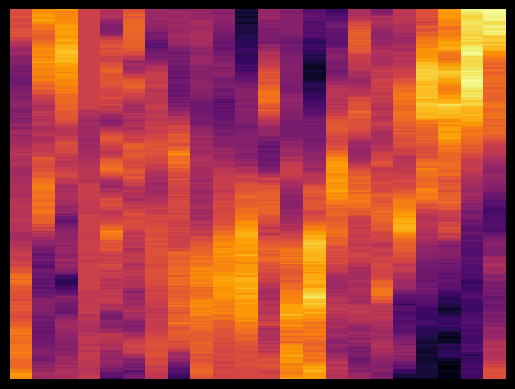

VD: 1081.9 Prediction: 1 Probability: tensor(0.9902)
Predicted indices: [0, 1]


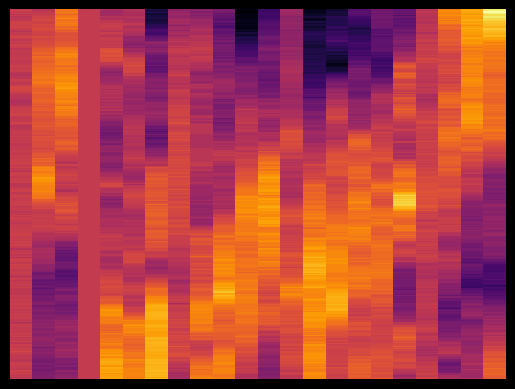

VD: 1083.15 Prediction: 2 Probability: tensor(0.9659)
Predicted indices: [2]


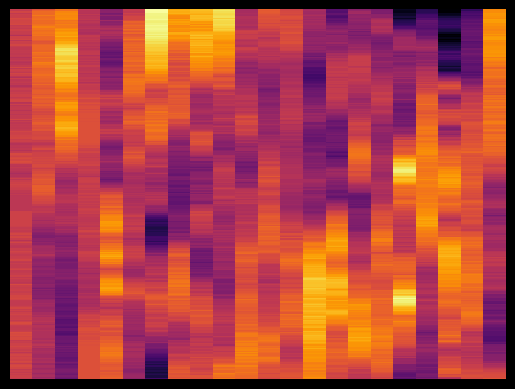

VD: 1083.65 Prediction: 6 Probability: tensor(0.9004)
Predicted indices: [6]


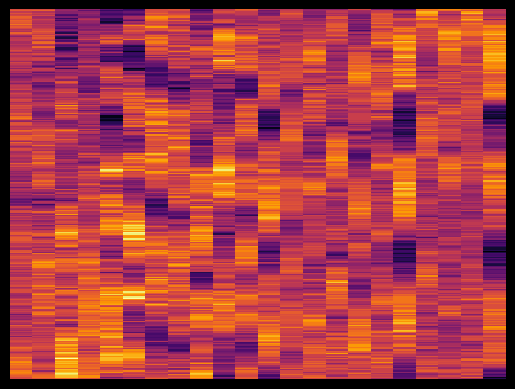

VD: 1089.65 Prediction: 6 Probability: tensor(0.9967)
Predicted indices: [5, 6, 7]


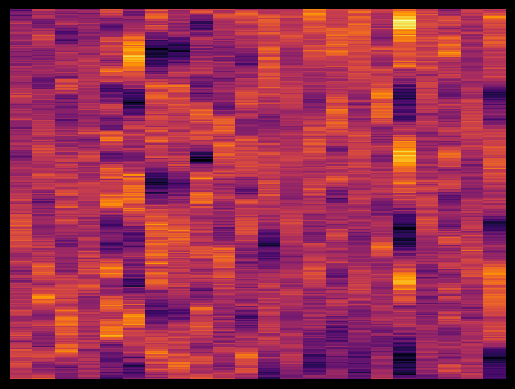

VD: 1094.4 Prediction: 20 Probability: tensor(0.9117)
Predicted indices: [20]


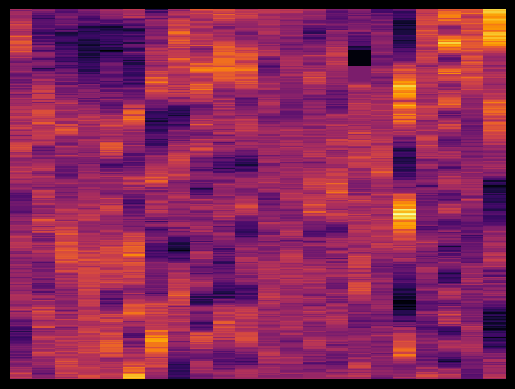

VD: 1096.9 Prediction: 18 Probability: tensor(0.9998)
Predicted indices: [17, 18, 19]


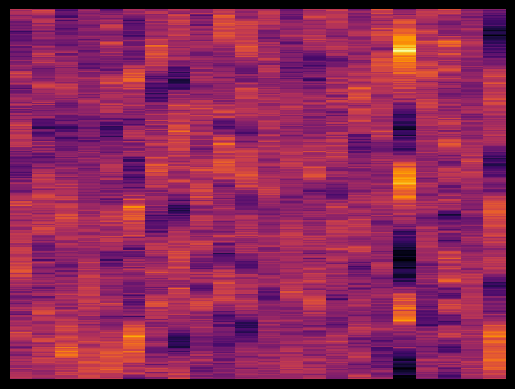

VD: 1097.4 Prediction: 18 Probability: tensor(0.9784)
Predicted indices: [18, 19]


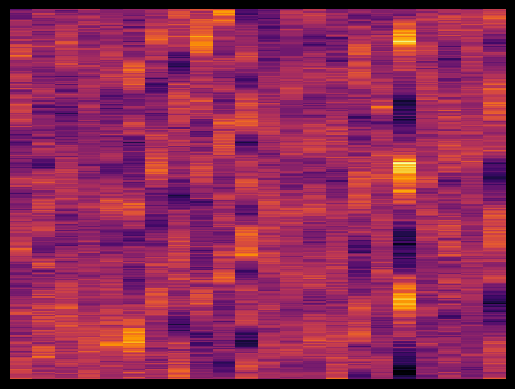

VD: 1099.4 Prediction: 19 Probability: tensor(0.9019)
Predicted indices: [19]


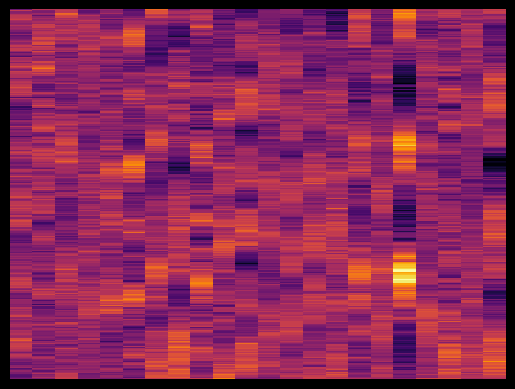

VD: 1100.65 Prediction: 19 Probability: tensor(0.9889)
Predicted indices: [18, 19]


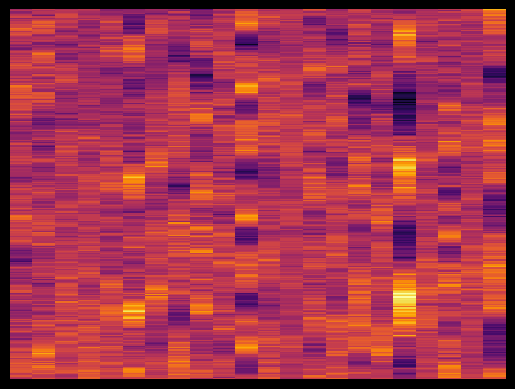

VD: 1102.15 Prediction: 18 Probability: tensor(0.9988)
Predicted indices: [18, 19]


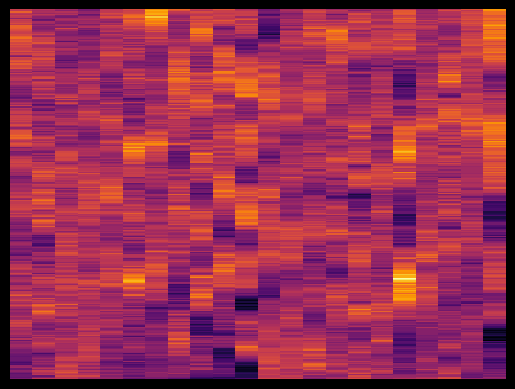

DbHealthCheck.cpp(146): Database service health check complete: Healthy
VD: 1104.15 Prediction: 20 Probability: tensor(0.9645)
Predicted indices: [20]


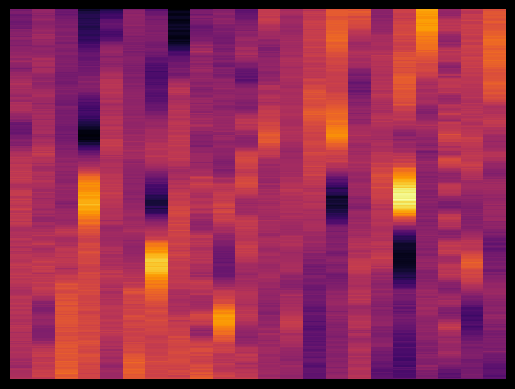

VD: 1105.65 Prediction: 6 Probability: tensor(0.9943)
Predicted indices: [5, 6]


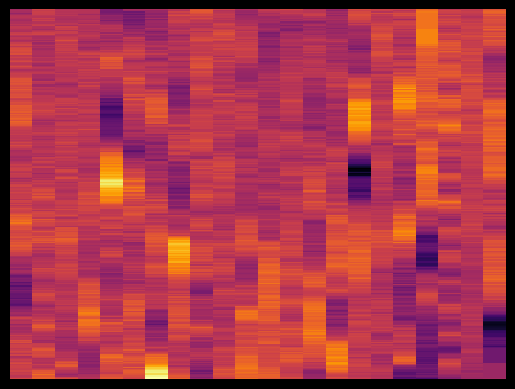

VD: 1119.65 Prediction: 16 Probability: tensor(0.9877)
Predicted indices: [16, 17]


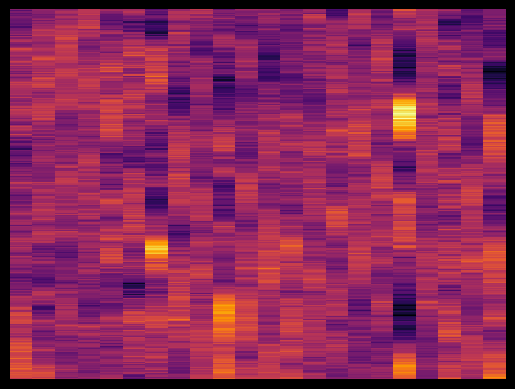

VD: 1120.4 Prediction: 19 Probability: tensor(0.9066)
Predicted indices: [19]


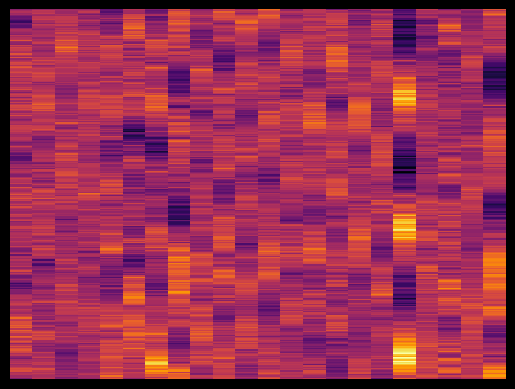

VD: 1123.15 Prediction: 19 Probability: tensor(0.9135)
Predicted indices: [19]


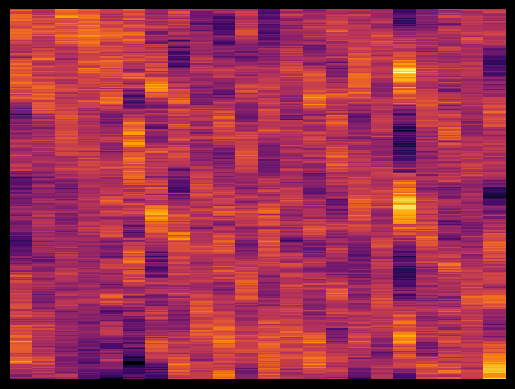

VD: 1125.15 Prediction: 20 Probability: tensor(0.9624)
Predicted indices: [0, 20]


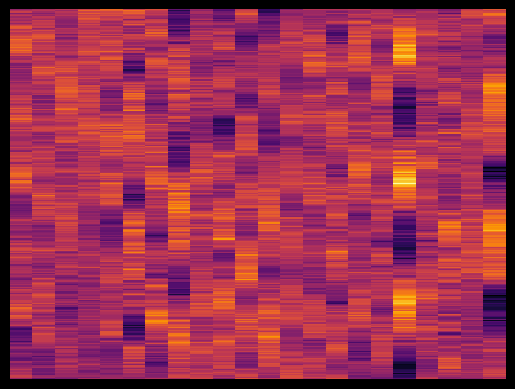

VD: 1126.4 Prediction: 20 Probability: tensor(0.9691)
Predicted indices: [0, 20]


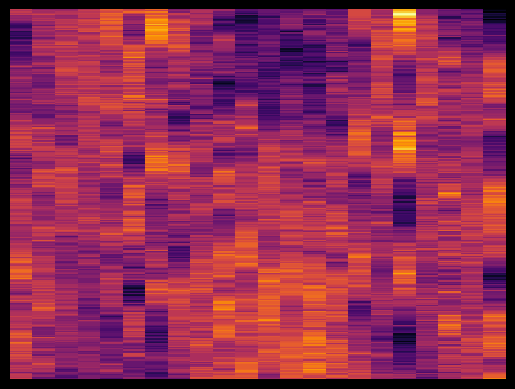

VD: 1127.65 Prediction: 20 Probability: tensor(0.9728)
Predicted indices: [0, 20]


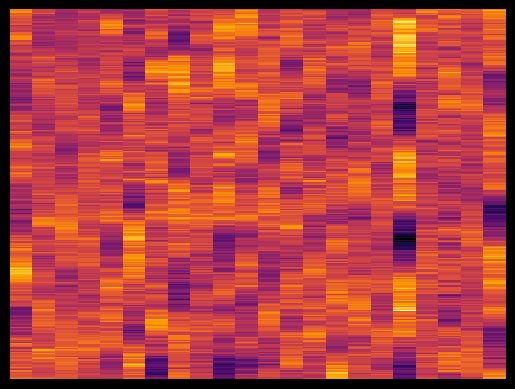

VD: 1130.65 Prediction: 20 Probability: tensor(0.9433)
Predicted indices: [0, 20]


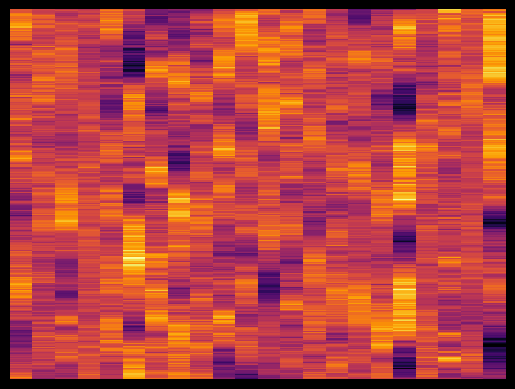

VD: 1131.9 Prediction: 18 Probability: tensor(0.9998)
Predicted indices: [18, 19]


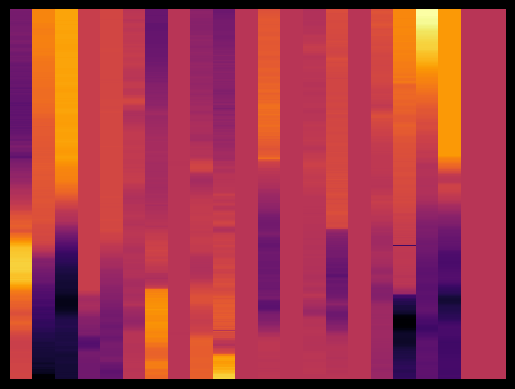

VD: 1138.65 Prediction: 1 Probability: tensor(0.9990)
Predicted indices: [0, 1]


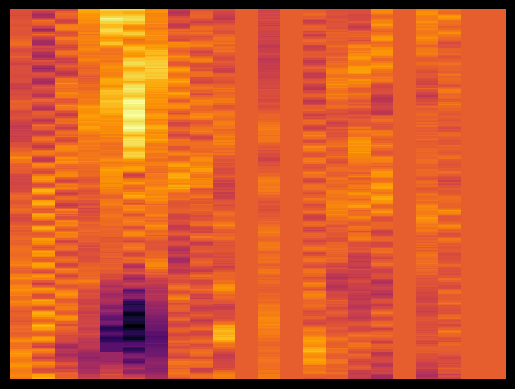

VD: 1141.65 Prediction: 6 Probability: tensor(0.9994)
Predicted indices: [5, 6, 7]


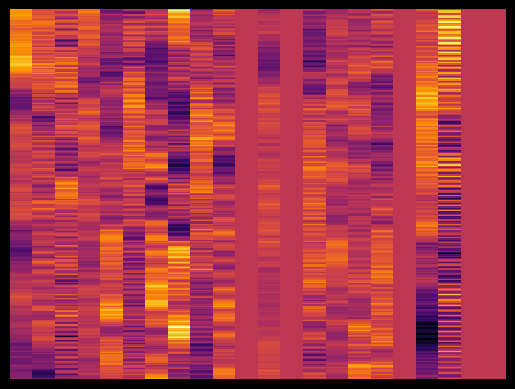

VD: 1143.15 Prediction: 19 Probability: tensor(0.9997)
Predicted indices: [18, 19, 20]


In [22]:
model.to(device)
positive_indices = [i for i, (p, prob) in enumerate(zip(preds, probs)) if p != 0 and prob > 0.9]
filtered_positive_indices = filter_consecutive(positive_indices)
print(len(filtered_positive_indices), "positive indices found")
positive_VD = [((img_start + img_end) / 2) for (img_start, img_end) in np.array(ranges)[filtered_positive_indices]]
positive_probs = [probs[i] for i in filtered_positive_indices]
positive_preds = [preds[i] for i in filtered_positive_indices]
out_dir = os.path.join(root_dir, "test_21class/pos")
os.makedirs(out_dir, exist_ok=True)
model.eval()
with torch.no_grad():
    for vd in positive_VD:

        img_std = gen_image(vd, show_im=True, normalize="std")[:20, :]
        img_patch = gen_image(vd, show_im=False, normalize="patch")[:20, :]
        img_patch_trend = seasonal_decompose(img_patch.T, model='additive', period=30, extrapolate_trend=2).trend.T
        img = np.stack((img_patch, img_patch_trend, img_std), axis=0)  # shape: (3, H, W)
        img = transform(img).unsqueeze(0).to(device)
        #np.save(os.path.join(out_dir, f"img_{vd:.2f}"), img)

        model.to(device)
        model.eval()
        raw_outputs = model(img.to(device))
        pred = raw_outputs.argmax().cpu().item()
        prob = raw_outputs.sigmoid().max().cpu()
        print("VD:", vd, "Prediction:", pred, "Probability:", prob)

        print("Predicted indices:", preds_list[vd])




## upload bookmarks

In [23]:
from __future__ import annotations

from ilipy import Session
from ilipy.channeldata import ChannelDataReader, ImageProfile
from ilipy.features import Bookmarks

from ilipyutils.ml_features.base import (
    AnomalyStatus,
    get_ml_models_info_list,
)
from ilipyutils.ml_features.insert import FeatureInsert
from ilipy import ClipTypes, TrackIndex, ViewDistance

session = Session(environment="research")
bookmarks_interface = Bookmarks(connector=session.database_connector)

feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8083, Concurrent Connections: 1
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8083, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8083) : 200, 21ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8083) : 200, 238ms


In [59]:
anomalies = bookmarks_interface.get_anomalies(inspectionId="09WMV85VAMM")
dent_anomalies = [a for a in anomalies if "Dent-Detection-v1" in a.tags]
len(dent_anomalies)


195

In [60]:
_ = [bookmarks_interface.delete_anomaly(a.feature.anomaly_feature_id) for a in dent_anomalies]

In [24]:
inspection_id = "09WMV85VAMM"
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v1"
)
model_info



MLModelInfo(model_name='Dent-Detection-v1', model_id=7, model_score_bound=[0, None], anomaly_type_id=200, anomaly_identification_type_id=403)

In [30]:
session = Session(environment="research")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8083, Concurrent Connections: 1
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvh-01.darkvision.local, Port: 8083, Concurrent Connections: 1
RestApi.cpp(72): ApiService Ping Response (http://storage-dvv-01.darkvision.local:8083) : 200, 54ms
RestApi.cpp(72): ApiService Ping Response (http://storage-dvh-01.darkvision.local:8083) : 200, 290ms
PySession.cpp(84): Initialized with inspection: 09WMV85VAMM
HttpRequestPool.cpp(81): [HttpRequestPool] Host: storage-dvv-01.darkvision.local, Port: 8083, Concurrent Connections: 3
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignm

In [ ]:
from ili_custom_data.load_model import ModelDataLoader

latest_model = ModelDataLoader.get_latest_model()
model_instance = latest_model(
    ml_confidence_score =0.85
)
print(model_instance)




version=2 field_of_view_issue=False tt_visible=False tt_t_visible=False feature_at_weld_seam=False workflow_name=None ml_confidence_score=0.85 crack_severity_score=None id_corrosion_severity_score=None od_corrosion_severity_score=None corrosion_length=None corrosion_width=None corrosion_depth=None corrosion_area=None corrosion_volume=None analyst_batch=None cr_length_mm=None cr_depth_mm=None cr_feature=None cr_feature_description=None cr_wall_location=None cr_orientation_ccw=None cr_wall_loss_percentage=None


In [26]:

session.set_active_inspection(inspection_id)
clips = session.get_clips_by_type(ClipTypes.ChannelData)

PySession.cpp(84): Initialized with inspection: 09WMV85VAMM


In [27]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 10) / 10
    # The upper bound is just 0.1 more
    upper = round(lower + 0.1, 1)
    
    return lower, upper

In [ ]:
vd = 121.9
# 5,6

profile = ImageProfile.ZeroAngle 
track_nums = [6]

min_track_num = min(track_nums)
max_track_num = max(track_nums)+1

bookmark_conf_score = prob
lower_bound, upper_bound = get_decimal_range(bookmark_conf_score)
extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}

start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(min_track_num), ViewDistance(vd-(patch_length/2))).value
end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(max_track_num), ViewDistance(vd+(patch_length/2))).value


model_instance = latest_model(
ml_confidence_score=bookmark_conf_score,)

anomaly_info = feature_insert.insert_ml_pred(
inspection_id=inspection_id,
tlbr_track_indices=(min_track_num, max_track_num),
tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
tlbr_scan_angles=(np.deg2rad(-15),np.deg2rad(15)),
model_info=model_info,
anomaly_status=AnomalyStatus.UNKNOWN,
image_profile=profile,
extra_tags=extra_tags,
ili_custom_data=model_instance
)

PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM


DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [ ]:
from ilipy.bookmarks import Bookmarks

TypeError: get_anomalies(): incompatible function arguments. The following argument types are supported:
    1. (self: ilipy.libs.ilipycpp.Bookmarks, inspectionId: str) -> List[ilipy.libs.ilipycpp.AnomalyInfo]

Invoked with: <ilipy.libs.ilipycpp.Bookmarks object at 0x768c36a3baf0>

In [34]:
dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(min_track_num), ViewDistance(vd-patch_length/2)).value,  dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(min_track_num), ViewDistance(vd+patch_length/2)).value

(1246107, 1249109)

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [ ]:
len(positive_probs)

195

DbHealthCheck.cpp(146): Database service health check complete: Healthy


In [63]:
for i, (vd, prob, pred) in enumerate(zip(positive_VD, positive_probs, positive_preds)):


    profile = ImageProfile.ZeroAngle 
    track_nums = preds_list[vd]
    #remove zero track and reduce one
    track_nums = [track_num-1 for track_num in track_nums if track_num != 0]
    min_track_num = min(track_nums)
    max_track_num = max(track_nums)+1

    bookmark_conf_score = prob
    lower_bound, upper_bound = get_decimal_range(bookmark_conf_score)
    extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}

    start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(min_track_num), ViewDistance(vd-patch_length/2)).value
    end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(max_track_num), ViewDistance(vd+patch_length/2)).value
    model_instance = latest_model(
    ml_confidence_score=bookmark_conf_score,)

    anomaly_info = feature_insert.insert_ml_pred(
    inspection_id=inspection_id,
    tlbr_track_indices=(min_track_num, max_track_num),
    tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
    tlbr_scan_angles=(np.deg2rad(-15),np.deg2rad(15)),
    model_info=model_info,
    anomaly_status=AnomalyStatus.UNKNOWN,
    image_profile=profile,
    extra_tags=extra_tags,
    ili_custom_data=model_instance
    )
	

PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 

IOStream.flush timed out


DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loadin

IOStream.flush timed out


DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loadin

IOStream.flush timed out


DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loading DistanceMaps asynchronously for inspection = 09WMV85VAMM
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> FrontSlot has a track assignment but no ut board assigned
PigSpatialModel.cpp(302): vehicle 3 -> disk 0 -> RearSlot has a track assignment but no ut board assigned
DistanceCorrelationController.cpp(208): Loadin

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
CognitoAuthenticator.cpp(842): Login Successful.
CognitoAuthenticator.cpp(883): Logged in as username: zahra.mirikharaji
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.c